# Imported and download required libraries

In [1]:
# !pip install scikit-learn
# !pip install missingno
# !pip install xgboost

In [2]:
# For Data Handling & System Utilities
import pandas as pd
import numpy as np
import random
import os

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, MaxNLocator
from IPython.display import Markdown, display
from IPython.display import display, HTML

# Statistical & Distribution Analysis
from scipy.stats import gamma
import missingno as msno
from scipy import stats

# Machine Learning (Data Splitting)
from sklearn.model_selection import train_test_split

In [3]:
# VIF score calculation
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
# Reset to default after (Good practice so other outputs aren't too huge)
# pd.reset_option('display.max_columns')

# Imported the data

In [6]:
# Define the file_path to access the file
file_path = r"C:\Users\danie\Downloads\Data Analytic\credit_loan_analysis\credit_loan_dataset.csv"

try:
    # Load the dataset
    df = pd.read_csv(file_path)
    
    # Quick verification of the data
    print("--- Dataset Loaded Successfully ---")
    print(f"Total Rows: {len(df):,}")
    print(f"Total Columns: {len(df.columns)}")
    
    # Display the first 5 rows to check formatting
    print("\nFirst 5 rows:")
    display(df.head())

except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}. Check the spelling or folder path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

--- Dataset Loaded Successfully ---
Total Rows: 400,000
Total Columns: 23

First 5 rows:


,person_age,gender,annual_inc,emp_length,emp_title,home_ownership,marriage_status,addr_cities,purpose,loan_amount,term,terms_remaining,int_rate,interest_band,grade,loan_to_value,collateral,mths_since_earliest_cr_line,regularity_of_inflows,fixed_obligation,existing_loans,existing_emi,default_status
0,36,Female,70500.0,14,Analyst,RENT,Yes,Manchester,Debt Consolidation,27200.0,36,0,9.376994,7.5-9.5,B,0.613280,Yes,27,Yes,1513.83,No,0.00,No
1,31,Male,26700.0,1,Accountant,MORTGAGE,Yes,Bristol,Home Improvement,51000.0,48,0,9.884824,9.5-11.5,B,0.724140,Yes,156,Yes,981.82,No,0.00,No
2,39,Male,73500.0,18,Analyst,MORTGAGE,No,Manchester,Car Purchase,27600.0,24,0,6.623931,6.4-7.5,A,0.383181,No,252,Yes,1332.15,Yes,487.02,No
3,28,Male,29000.0,7,Techican,RENT,Yes,Glasgow,Home Improvement,65500.0,72,0,8.383299,7.5-9.5,B,0.362882,No,120,Yes,778.53,Yes,1135.30,No
4,45,Male,42900.0,8,Nurse,RENT,No,London,Debt Consolidation,16400.0,60,0,9.679782,9.5-11.5,B,0.562121,No,81,Yes,1274.00,Yes,468.29,No


# Inspecting the data

In [7]:
# Check the structure of the data
print(df.dtypes)
print(f'Dataset Dimensions: Rows and Columns {df.shape}')

person_age                       int64
gender                          object
annual_inc                     float64
emp_length                       int64
emp_title                       object
home_ownership                  object
marriage_status                 object
addr_cities                     object
purpose                         object
loan_amount                    float64
term                             int64
terms_remaining                  int64
int_rate                       float64
interest_band                   object
grade                           object
loan_to_value                  float64
collateral                      object
mths_since_earliest_cr_line      int64
regularity_of_inflows           object
fixed_obligation               float64
existing_loans                  object
existing_emi                   float64
default_status                  object
dtype: object
Dataset Dimensions: Rows and Columns (400000, 23)


In [8]:
# Print summary statistics
display(df.describe(include='all'))

,person_age,gender,annual_inc,emp_length,emp_title,home_ownership,marriage_status,addr_cities,purpose,loan_amount,term,terms_remaining,int_rate,interest_band,grade,loan_to_value,collateral,mths_since_earliest_cr_line,regularity_of_inflows,fixed_obligation,existing_loans,existing_emi,default_status
count,400000.000000,400000,400000.00000,400000.000000,400000,400000,400000,400000,400000,400000.000000,400000.000000,400000.000000,400000.000000,400000,400000,400000.000000,400000,400000.000000,400000,400000.000000,400000,400000.000000,400000
unique,NaN,3,NaN,NaN,10,4,2,8,5,NaN,NaN,NaN,NaN,4,4,NaN,2,NaN,2,NaN,2,NaN,2
top,NaN,Male,NaN,NaN,Sales,MORTGAGE,Yes,London,Debt Consolidation,NaN,NaN,NaN,NaN,9.5-11.5,B,NaN,Yes,NaN,Yes,NaN,Yes,NaN,No
freq,NaN,199997,NaN,NaN,40361,232464,212512,128343,140110,NaN,NaN,NaN,NaN,140181,166324,NaN,239816,NaN,360275,NaN,239662,NaN,361914
mean,33.070750,NaN,39346.50550,8.625100,NaN,NaN,NaN,NaN,NaN,32632.386000,48.029250,3.272442,10.204639,NaN,NaN,0.649756,NaN,134.835385,NaN,1065.530195,NaN,390.766426,NaN
std,7.026797,NaN,16373.40894,5.863383,NaN,NaN,NaN,NaN,NaN,23293.704968,23.987206,11.800465,1.884661,NaN,NaN,0.202098,NaN,73.888782,NaN,511.286644,NaN,513.541351,NaN
min,21.000000,NaN,5500.00000,0.000000,NaN,NaN,NaN,NaN,NaN,5000.000000,12.000000,0.000000,6.400000,NaN,NaN,0.300000,NaN,12.000000,NaN,138.830000,NaN,0.000000,NaN
25%,28.000000,NaN,27700.00000,4.000000,NaN,NaN,NaN,NaN,NaN,13700.000000,24.000000,0.000000,8.758690,NaN,NaN,0.474365,NaN,77.000000,NaN,701.720000,NaN,0.000000,NaN
50%,32.000000,NaN,36300.00000,8.000000,NaN,NaN,NaN,NaN,NaN,26700.000000,48.000000,0.000000,10.198909,NaN,NaN,0.649820,NaN,123.000000,NaN,962.330000,NaN,180.250000,NaN
75%,38.000000,NaN,47600.00000,12.000000,NaN,NaN,NaN,NaN,NaN,48000.000000,72.000000,0.000000,11.638735,NaN,NaN,0.824489,NaN,180.000000,NaN,1314.642500,NaN,618.065000,NaN


In [9]:
df['default_status'].value_counts()

default_status
No     361914
Yes     38086
Name: count, dtype: int64

In [10]:
# Summary of missing (NaN/Null) and zero values per column then sort by highest combined NaN/Null + Zeros
missing_summary = (
    # Get the data type (e.g., float, object) for every column in the DataFrame
    df.dtypes.to_frame(name="Type")
    # Join the 'Type' column with a new DataFrame containing calculated statistics
    .join(pd.DataFrame({
        "Missing values": df.isna().sum(), # Calculate the count of missing (NaN or Null) values for each column
        "Percentage Missing": round(df.isna().mean() * 100, 2), # Calculate the percentage of missing values, round to 2 decimal places
        "Zeros": (df == 0).sum(),         # Calculate the count of explicit zero (0) values for each column
        "Percentage Zeros": round((df == 0).mean() * 100, 2)})) # Calculate the percentage of explicit zero values, round to 2 decimal places
    # Use .assign() to create a new calculated column
    .assign(**{"NaN/Null + Zeros": lambda df: df["Missing values"] + df["Zeros"]})
    # Sort the resulting DataFrame in descending order based on the combined count
    .sort_values(by="NaN/Null + Zeros", ascending=False))

# Display the final summary table
display(missing_summary)

,Type,Missing values,Percentage Missing,Zeros,Percentage Zeros,NaN/Null + Zeros
terms_remaining,int64,0,0.0,361914,90.48,361914
existing_emi,float64,0,0.0,160338,40.08,160338
emp_length,int64,0,0.0,16191,4.05,16191
int_rate,float64,0,0.0,0,0.00,0
existing_loans,object,0,0.0,0,0.00,0
fixed_obligation,float64,0,0.0,0,0.00,0
regularity_of_inflows,object,0,0.0,0,0.00,0
mths_since_earliest_cr_line,int64,0,0.0,0,0.00,0
collateral,object,0,0.0,0,0.00,0
loan_to_value,float64,0,0.0,0,0.00,0


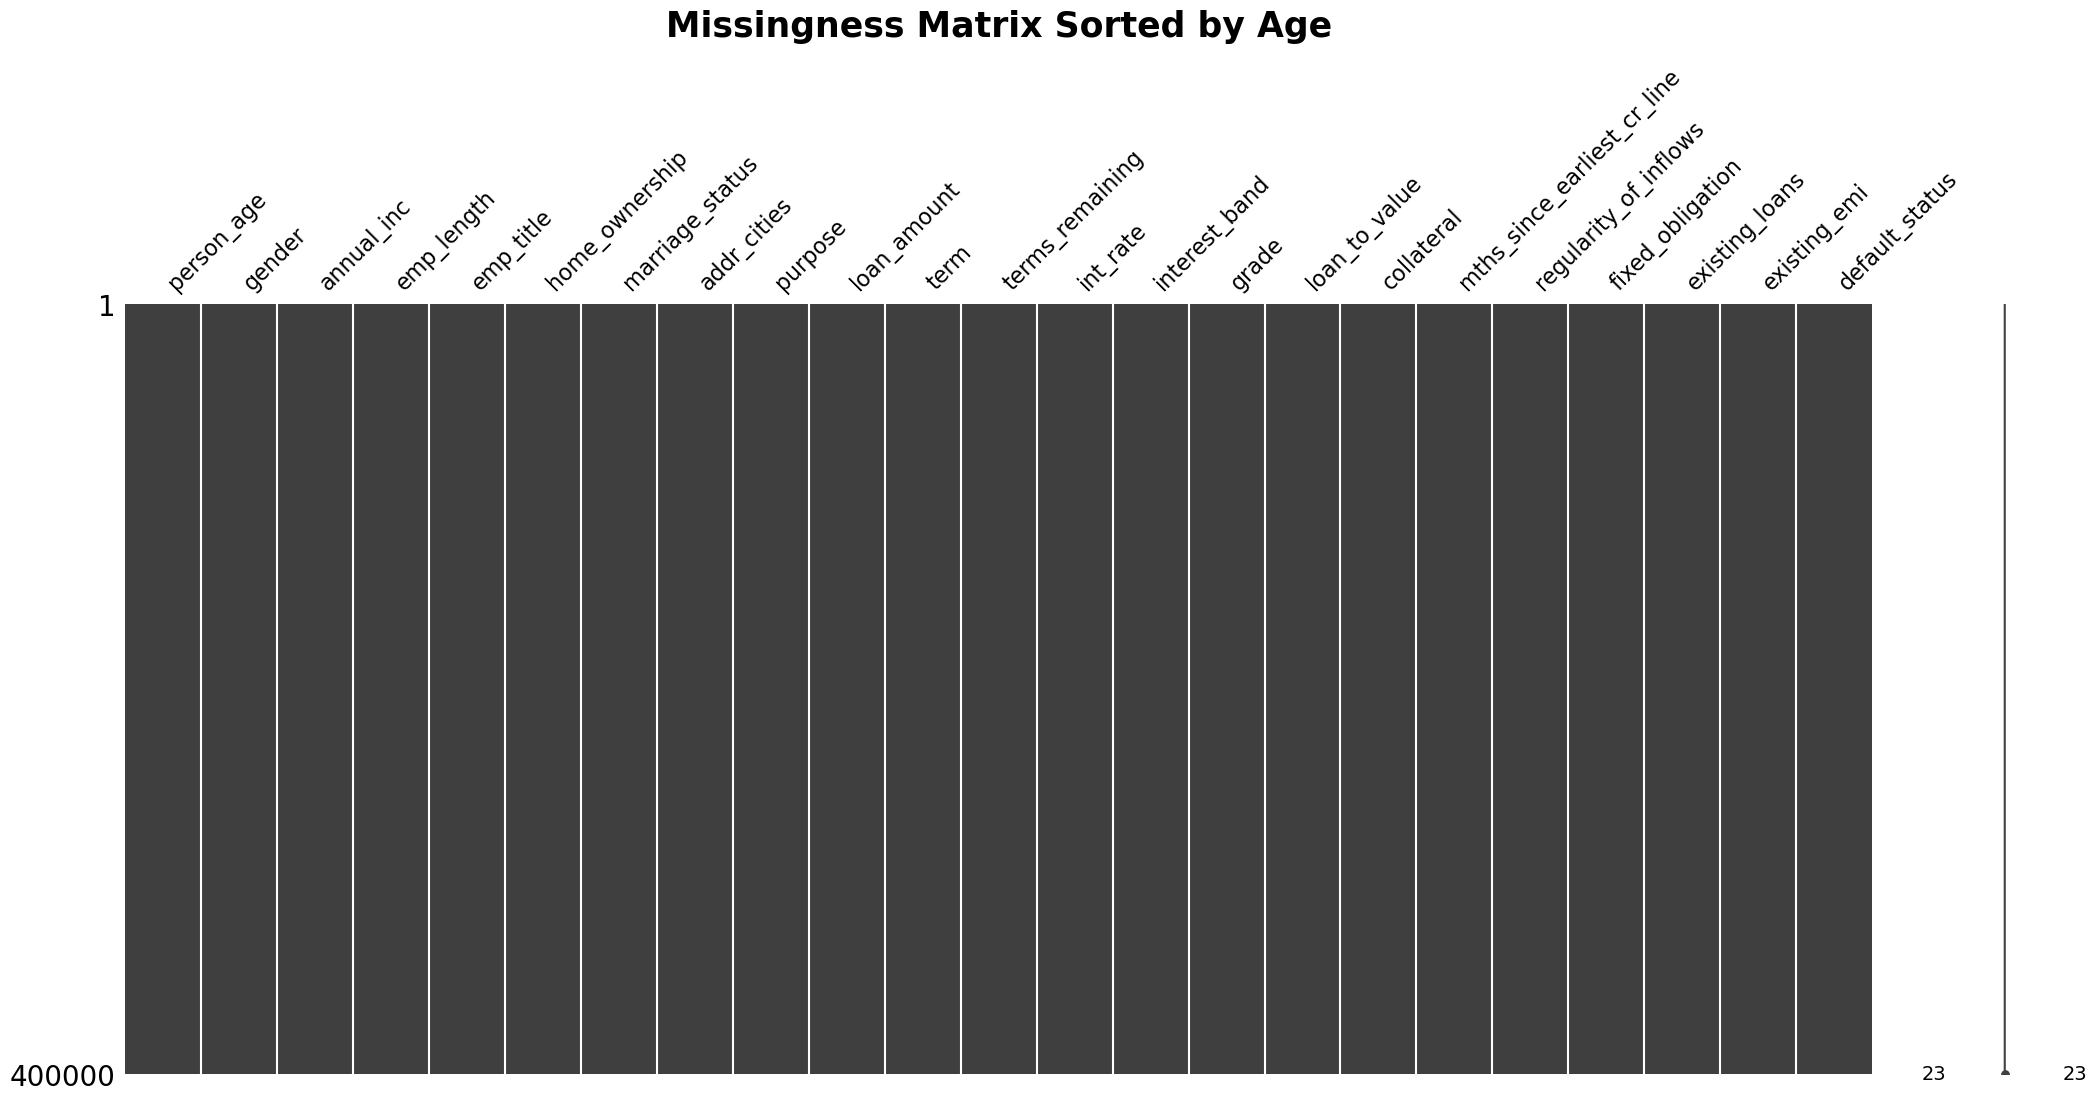

In [11]:
# Sort cr_loan by age and visualize missingness matrix
df = df.sort_values(by='person_age')
msno.matrix(df)
plt.title("Missingness Matrix Sorted by Age", fontsize=25, fontweight='bold', pad=20)
plt.show()

# Data Cleaning

#### Duplication

In [12]:
# Count total exact duplicate rows
duplicates = df.duplicated().sum()
print(f"Total exact duplicate rows found: {duplicates}")

# Drop duplicates if any
# df = df.drop_duplicates()

# Re-check for duplicates
# duplicates = df.duplicated(keep=False)
# print(f'Number of duplicate rows: {duplicates.sum()}')

Total exact duplicate rows found: 0


#### Create demographic group followed defined age ranges, income ranges and loan-to-value ranges

In [13]:
# Define the boundaries (bins) for the age groups (18-35, 36-60, 60-max)
bins_age = [18, 35, 60, np.inf]

# Define the corresponding labels for each bin.
labels_age = ['Young', 'Middle', 'Old']

# Create the new 'age_group' column using pd.cut()
df['age_group'] = pd.cut(df['person_age'],
    bins=bins_age, labels=labels_age,
    right=True, include_lowest=True )

# Define the boundaries (bins) for the income groups (0-20000, 20000-55000, 55000-max)
bins_income = [0, 20000, 55000, np.inf]

# Define the corresponding labels for each bin.
labels_income = ['Low Income', 'Middle Income', 'High Income']

# Create the new 'income_group' column using pd.cut()
df['income_group'] = pd.cut(df['annual_inc'],
    bins=bins_income, labels=labels_income,
    right=True, include_lowest=True)

# Define boundaries: 0-0.60 (Low), 0.60-0.80 (Moderate), 0.80-1.0 (High)
bins_ltv = [0, 0.60, 0.80, 1.0]

# Define corresponding labels for each bin
labels_ltv = ['Low', 'Moderate', 'High']

# Create the new 'ltv_group' column using pd.cut()
df['ltv_group'] = pd.cut(df['loan_to_value'], 
    bins=bins_ltv, labels=labels_ltv, 
    right=True, include_lowest=True)

#### Check for potential logical error

In [14]:
# Create a mask where credit history is greater than age
error_mask = df['mths_since_earliest_cr_line'] > (df['person_age'] * 12)

# Identify how many rows are affected
print(f"Number of rows with logical errors: {error_mask.sum()}")

Number of rows with logical errors: 0


# Exploratory Data Analysis

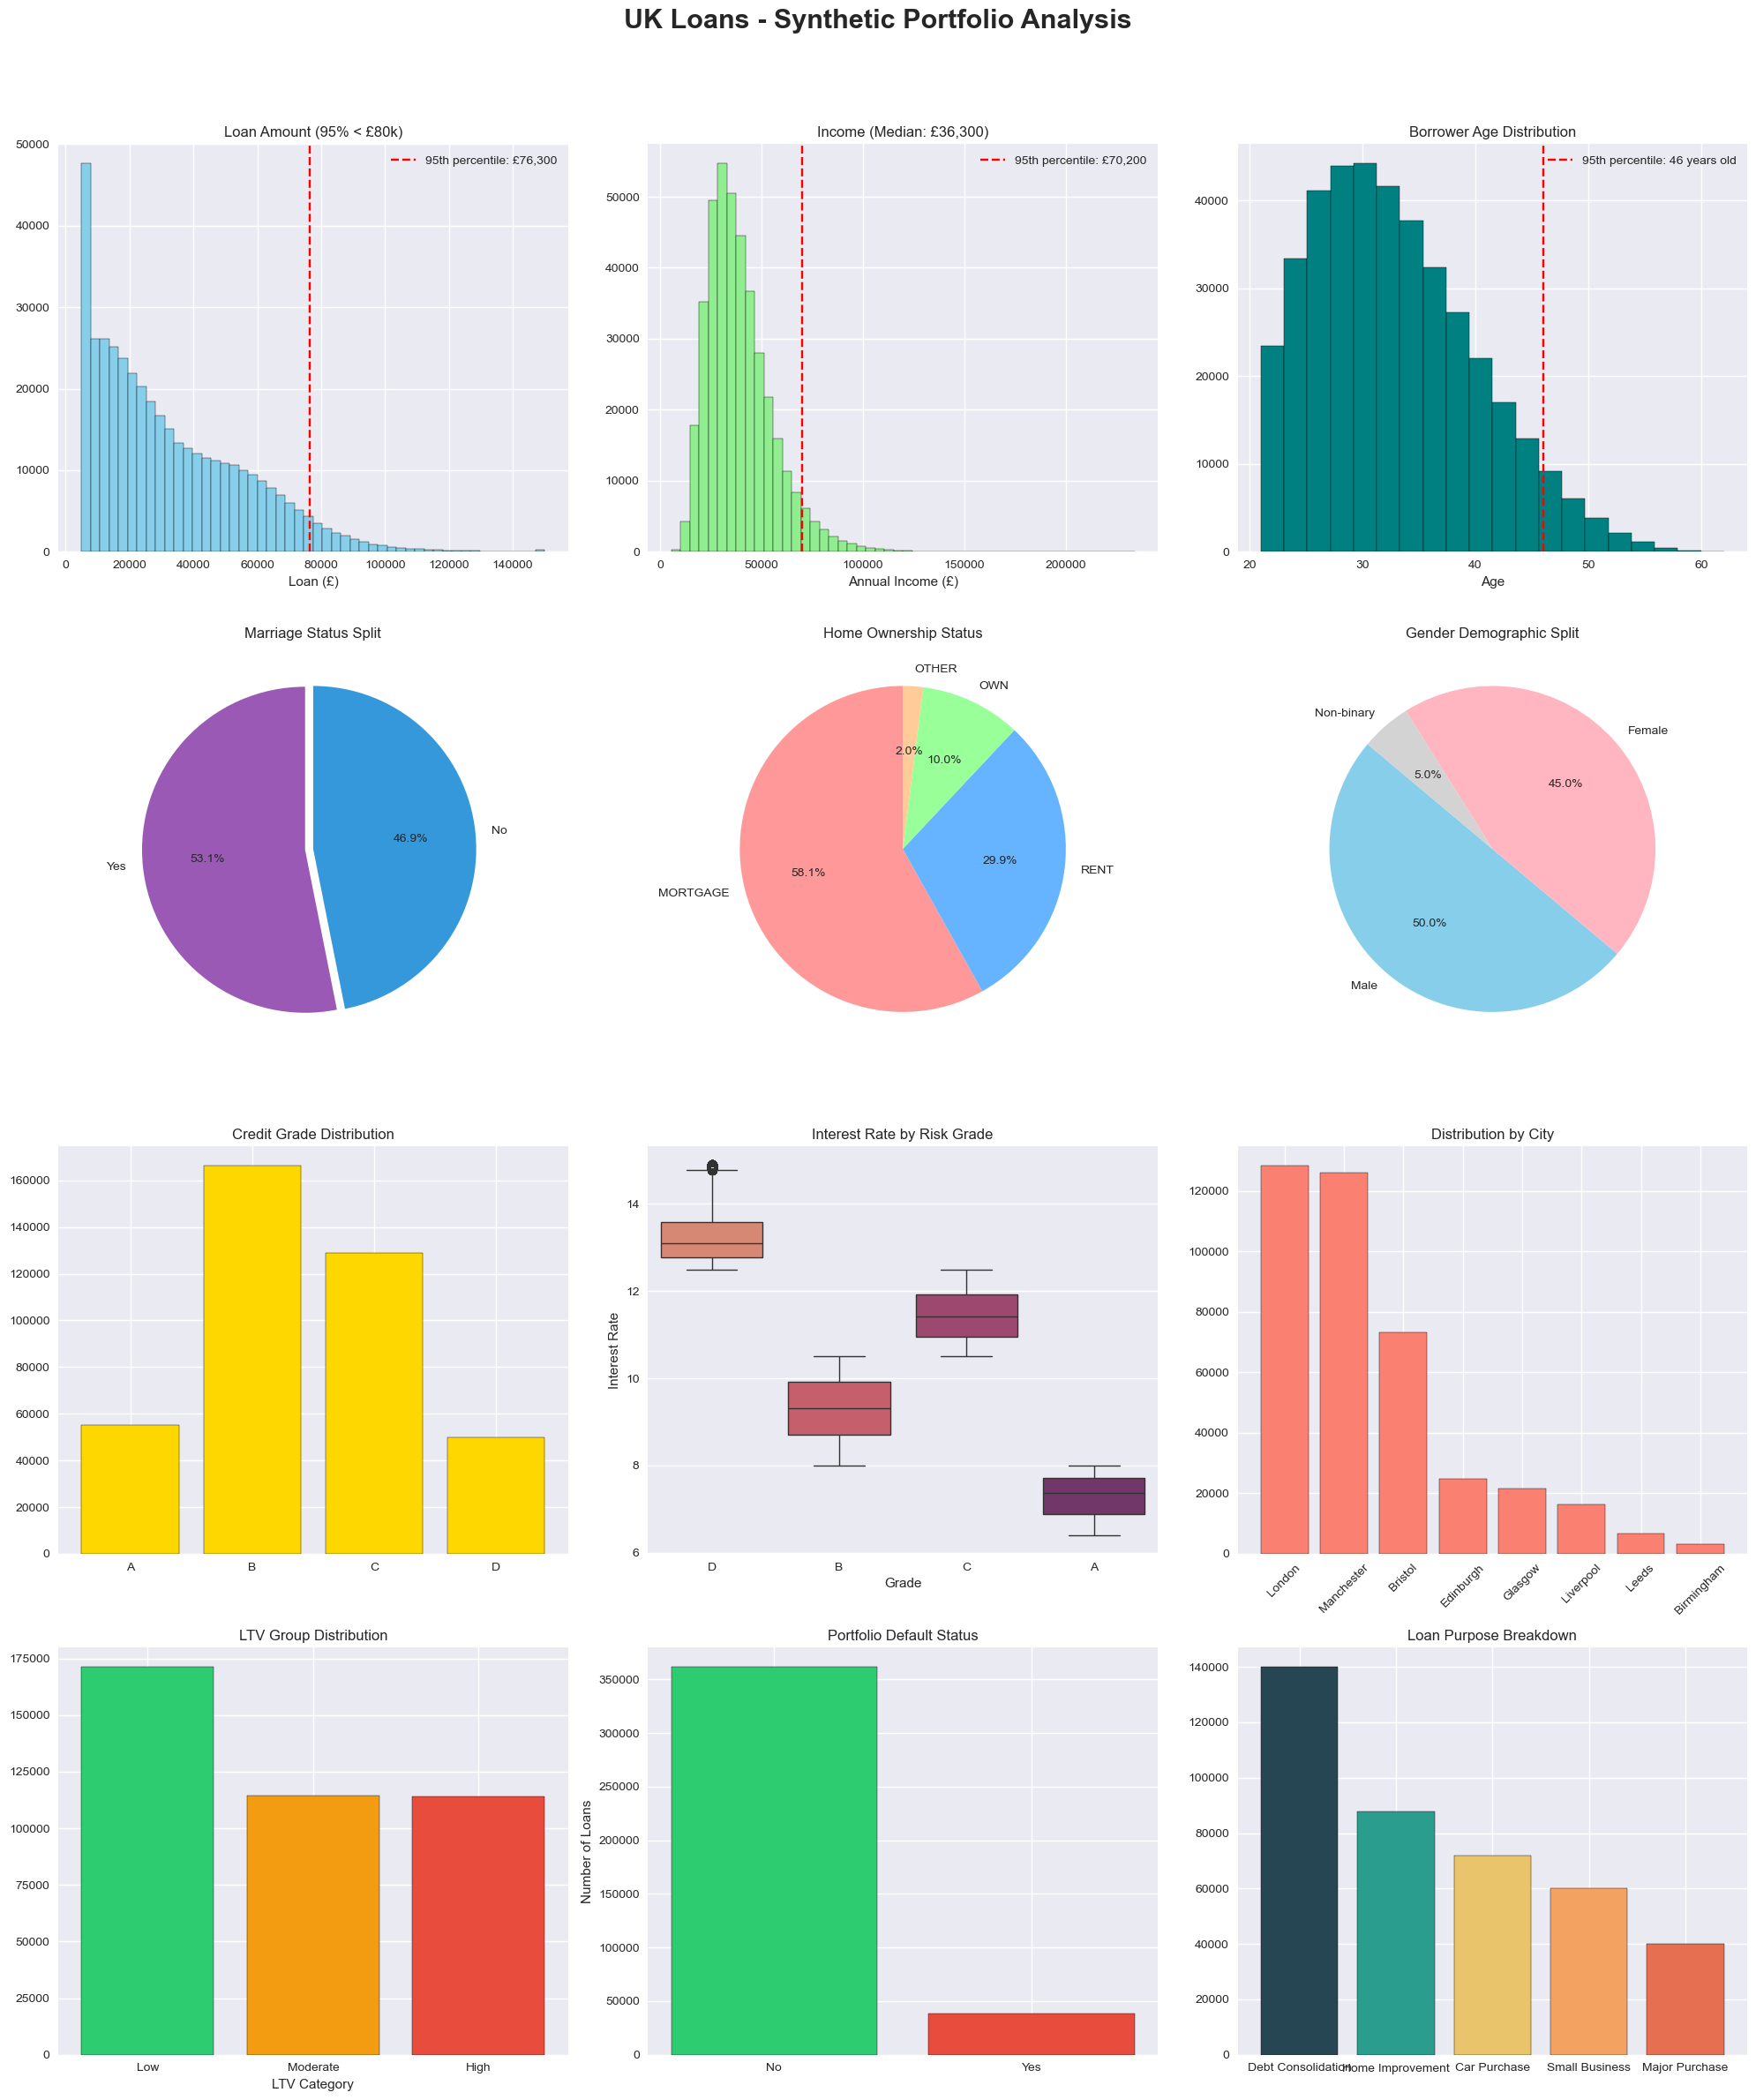


             SMART LOAN GRADING REPORT
Loan 95th %ile:   £76,300
Loans at £100k:   38 (Minimal Spike)
Max Loan: £150,000
Min Loan: £5,000
Income Median:    £36,300
Default Rate:     9.52%


In [15]:
# =============================================
# PLOTS (Revised for Smooth Taper)
# =============================================
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(4, 3, figsize=(20, 25))
fig.suptitle("UK Loans - Synthetic Portfolio Analysis", fontsize=22, fontweight='bold')

# 1. Loan Amount Distribution (Tapered Gamma Result)
axes[0,0].hist(df["loan_amount"], bins=50, color='skyblue', edgecolor='black')
p95_loan = np.percentile(df['loan_amount'], 95)
axes[0,0].axvline(p95_loan, color='red', linestyle='--', label=f'95th percentile: £{p95_loan:,.0f}')
axes[0,0].set_title(f"Loan Amount (95% < £80k)")
axes[0,0].set_xlabel("Loan (£)")
axes[0,0].legend()

# 2. Income Distribution
axes[0,1].hist(df["annual_inc"], bins=50, color='lightgreen', edgecolor='black')
p95_income = np.percentile(df['annual_inc'], 95)
axes[0,1].axvline(p95_income, color='red', linestyle='--', label=f'95th percentile: £{p95_income:,.0f}')
axes[0,1].set_title(f"Income (Median: £{df['annual_inc'].median():,.0f})")
axes[0,1].set_xlabel("Annual Income (£)")
axes[0,1].legend()

# 3. Age Distribution
axes[0,2].hist(df["person_age"], bins=20, color='teal', edgecolor='black')
p95_age = np.percentile(df['person_age'], 95)
axes[0,2].axvline(p95_age, color='red', linestyle='--', label=f'95th percentile: {p95_age:,.0f} years old')
axes[0,2].set_title("Borrower Age Distribution")
axes[0,2].set_xlabel("Age")
axes[0,2].legend()

# 4. Marriage Status Breakdown
marriage_counts = df['marriage_status'].value_counts()
axes[1,0].pie(marriage_counts, labels=marriage_counts.index, autopct='%1.1f%%', 
              colors=['#9b59b6', '#3498db'], startangle=90, explode=(0.05, 0))
axes[1,0].set_title("Marriage Status Split")

# 5. Home Ownership
home_counts = df['home_ownership'].value_counts()
axes[1,1].pie(home_counts, labels=home_counts.index, autopct='%1.1f%%', 
              colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'], startangle=90)
axes[1,1].set_title("Home Ownership Status")

# 6. Gender Distribution
gender_counts = df['gender'].value_counts()
axes[1,2].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', 
              colors=['#87CEEB','#FFB6C1','#D3D3D3'], startangle=140)
axes[1,2].set_title("Gender Demographic Split")

# 7. Loan Grade
grade_counts = df['grade'].value_counts().sort_index()
axes[2,0].bar(grade_counts.index, grade_counts.values, color='gold', edgecolor='black')
axes[2,0].set_title("Credit Grade Distribution")

# 8. Interest Rate by Risk Grade
sns.boxplot(x='grade', y='int_rate', hue='grade', data=df, ax=axes[2,1], palette='flare', legend=False)
axes[2,1].set_title("Interest Rate by Risk Grade")
axes[2,1].set_xlabel("Grade")
axes[2,1].set_ylabel("Interest Rate")

# 9. City Distribution
city_counts = df['addr_cities'].value_counts()
axes[2,2].bar(city_counts.index, city_counts.values, color='salmon', edgecolor='black')
axes[2,2].set_title("Distribution by City")
axes[2,2].tick_params(axis='x', rotation=45)

# 10. Loan-to-Value (LTV) Distribution
ltv_counts = df['ltv_group'].value_counts().sort_index()
axes[3,0].bar(ltv_counts.index.astype(str), ltv_counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
axes[3,0].set_title("LTV Group Distribution")
axes[3,0].set_xlabel("LTV Category")

# 11. Default Status (Binary Analysis)
default_counts = df['default_status'].value_counts()
axes[3,1].bar(default_counts.index, default_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[3,1].set_title("Portfolio Default Status")
axes[3,1].set_ylabel("Number of Loans")

# 12. Loan purpose breakdown
purpose_counts = df['purpose'].value_counts()
axes[3,2].bar(purpose_counts.index, purpose_counts.values, color=['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51'], edgecolor='black')
axes[3,2].set_title("Loan Purpose Breakdown")

# Visualize
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# =============================================
# UPDATED REPORT CARD
# =============================================
print("\n" + "="*60)
print("             SMART LOAN GRADING REPORT")
print("="*60)
print(f"Loan 95th %ile:   £{np.percentile(df['loan_amount'], 95):,.0f}")
print(f"Loans at £100k:   {np.sum(df['loan_amount'] == 100000)} (Minimal Spike)")
print(f"Max Loan: £{df['loan_amount'].max():,.0f}")
print(f"Min Loan: £{df['loan_amount'].min():,.0f}")
print(f"Income Median:    £{df['annual_inc'].median():,.0f}")
print(f"Default Rate:     {(df['default_status'] == 'Yes').mean()*100:.2f}%")
# print("-" * 60)
# print("Grade Distribution:")
# print(df["grade"].value_counts().sort_index().to_string())
# print("="*60)
# print("Loan-to-value Distribution:")
# print(df['ltv_group'].value_counts().sort_index())

In [16]:
# Create a cross table of home ownership, loan status, and grade
display(pd.crosstab([df['gender']], 
                    [df['purpose'], df['grade']]))

purpose    Car Purchase                     Debt Consolidation                \
grade                 A      B      C     D                  A      B      C   
gender                                                                         
Female             4422  13427  10427  3999               8734  26210  20259   
Male               4967  14890  11711  4562               9680  29351  22362   
Non-binary          508   1421   1208   427                896   2913   2228   

purpose          Home Improvement                     Major Purchase        \
grade          D                A      B      C     D              A     B   
gender                                                                       
Female      7816             5440  16395  12750  4999           2495  7561   
Male        8747             5978  18298  14130  5402           2702  8434   
Non-binary   914              584   1840   1410   548            267   796   

purpose                Small Business                     
grade          C     D              A      B     C     D  
gender                                                    
Female      5854  2301           3769  11201  8782  3287  
Male        6364  2447           4166  12348  9796  3662  
Non-binary   682   253            386   1239   972   383

In [17]:
pd.crosstab(
    index=[df['income_group'], df['grade']], 
    columns=df['ltv_group'])

ltv_group              Low  Moderate   High
income_group  grade                        
Low Income    A       3824        66      0
              B       7359      3580    465
              C        722      3826   4263
              D          7       336   2987
Middle Income A      42101       778      3
              B      84049     40747   5501
              C       7751     44461  48545
              D         60      3741  35247
High Income   A       8077       144      1
              B      15935      7598   1090
              C       1537      8585   9245
              D         10       751   6608

# Computing EAD

$$EAD = P \times \frac{(1 + r)^n - (1 + r)^p}{(1 + r)^n - 1}$$
Where:
- $P$ = Original Loan Amount
- $r$ = Monthly Interest Rate (Annual Rate / 12)
- $n$ = Total Number of Terms (Months)
- $p$ = Number of installments already paid ($n - \text{terms\_remaining}$)

In [18]:
# Convert annual interest rate to monthly decimal
monthly_rate = (df['int_rate'] / 100) / 12

# Calculate number of payments already made
payments_made = df['term'] - df['terms_remaining']

# Calculate EAD using the amortization formula
numerator = (1 + monthly_rate)**df['term'] - (1 + monthly_rate)**payments_made
denominator = (1 + monthly_rate)**df['term'] - 1

df['ead'] = np.where(
    df['default_status'] == 'Yes',
    (df['loan_amount'] * (numerator / denominator)).round(2), 0)

# Cleanup: EAD cannot be higher than the original loan amount due to rounding
df['ead'] = np.minimum(df['ead'], df['loan_amount'])

# Summary Statistics
print(f"Average Original Loan (Defaulters): £{df[df['default_status'] == 'Yes']['loan_amount'].mean():.2f}")
print(f"Average EAD (Defaulters): £{df[df['default_status'] == 'Yes']['ead'].mean():.2f}")
print(f"EAD as % of Loan Amount: {(df[df['default_status'] == 'Yes']['ead'].sum() / df[df['default_status'] == 'Yes']['loan_amount'].sum() * 100):.2f}%")

Average Original Loan (Defaulters): £32641.37
Average EAD (Defaulters): £24478.98
EAD as % of Loan Amount: 74.99%


# Treatment

#### Numeric and Categorical classification

In [19]:
# Select columns with numerical data types (integers, floats) and store their names in a list
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()

# Select columns with object (string/text) or category data types and store their names in a list
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Count the number of columns in each list
num_numeric = len(numerical_columns)
num_categorical = len(categorical_columns)

# Preview the columns
print(f"Numeric data columns: {numerical_columns}")
print(f"Categorical data columns: {categorical_columns}")

# Display the counts
print(f"Number of Numeric columns: {num_numeric}")
print(f"Number of Categorical columns: {num_categorical}")
print(f"Total columns identified: {num_numeric + num_categorical}")

Numeric data columns: ['person_age', 'annual_inc', 'emp_length', 'loan_amount', 'term', 'terms_remaining', 'int_rate', 'loan_to_value', 'mths_since_earliest_cr_line', 'fixed_obligation', 'existing_emi', 'ead']
Categorical data columns: ['gender', 'emp_title', 'home_ownership', 'marriage_status', 'addr_cities', 'purpose', 'interest_band', 'grade', 'collateral', 'regularity_of_inflows', 'existing_loans', 'default_status', 'age_group', 'income_group', 'ltv_group']
Number of Numeric columns: 12
Number of Categorical columns: 15
Total columns identified: 27


In [20]:
# Ensure numeric columns use the correct dtype (float64 for calculations)
df[numerical_columns] = df[numerical_columns].astype("float64")

# Ensure categorical columns use the 'category' dtype
exclude_cols = ["age_group", "income_group", "ltv_group"]

# Identify object columns eligible for conversion
categorical_columns = df.select_dtypes(include="object").columns.difference(exclude_cols)
df[categorical_columns] = df[categorical_columns].astype("category")

In [21]:
# Re-inspect the information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400000 entries, 373018 to 242284
Data columns (total 27 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   person_age                   400000 non-null  float64 
 1   gender                       400000 non-null  category
 2   annual_inc                   400000 non-null  float64 
 3   emp_length                   400000 non-null  float64 
 4   emp_title                    400000 non-null  category
 5   home_ownership               400000 non-null  category
 6   marriage_status              400000 non-null  category
 7   addr_cities                  400000 non-null  category
 8   purpose                      400000 non-null  category
 9   loan_amount                  400000 non-null  float64 
 10  term                         400000 non-null  float64 
 11  terms_remaining              400000 non-null  float64 
 12  int_rate                     400000 non-null

#### Checking Correlation among Features

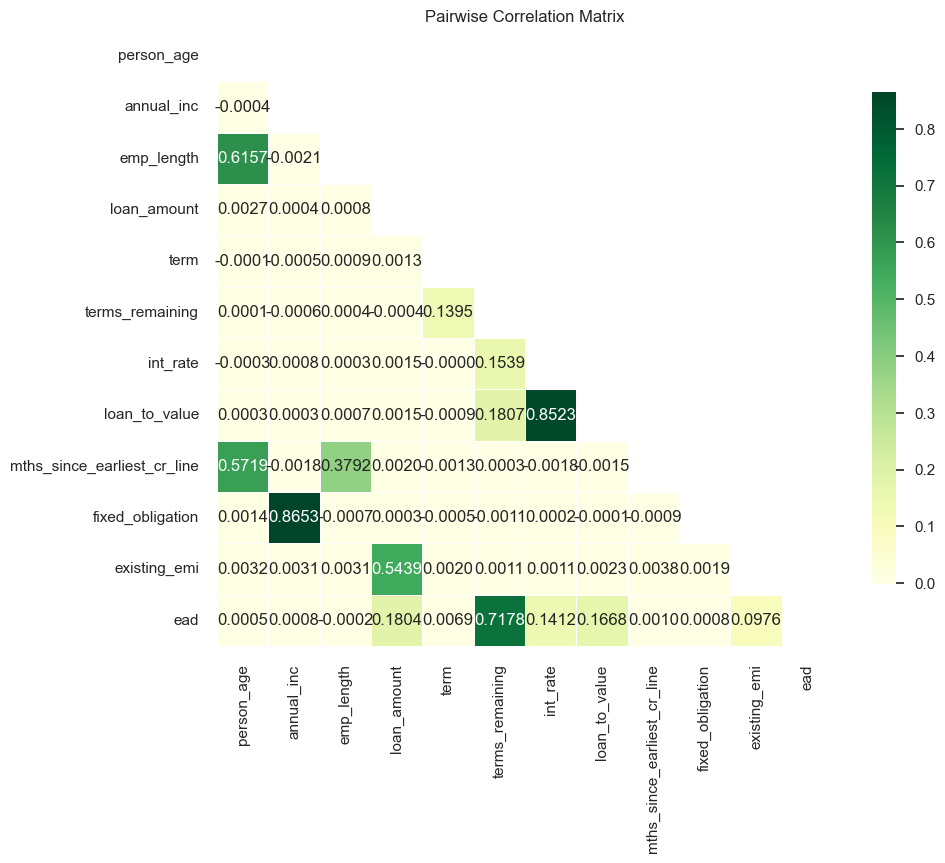


--- Highly Correlated Pairs ---


,Feature 1,Feature 2,Correlation
0,annual_inc,fixed_obligation,0.865330
1,int_rate,loan_to_value,0.852306
2,terms_remaining,ead,0.717849
3,person_age,emp_length,0.615661


In [22]:
# 1. Setup and Correlation Calculation
sns.set_theme(style="white")
corr = df[numerical_columns].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

# 2. Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, cmap='YlGn', fmt=".4f", linewidths=0.5, square=True, cbar_kws={"shrink": .8})
plt.title("Pairwise Correlation Matrix")
plt.show()

# 3. Concise Filtering & Display
high_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().reset_index()
high_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Filter and display
result = high_corr[high_corr['Correlation'].abs() > 0.6].sort_values(by='Correlation', ascending=False)

print("\n--- Highly Correlated Pairs ---")
display(result.reset_index(drop=True))

#### Removing High Multicolliear Features

The VIF calculation code is based on this resource: 
- https://www.datacamp.com/tutorial/variance-inflation-factor

In [23]:
# 1. Select only numeric features (VIF doesn't apply to strings/categories) & drop target variable if it's in the dataframe
target_col = 'default_status' 
vif_features = [col for col in numerical_columns if col != target_col]
numeric_df = df.select_dtypes(include=['number']).dropna()

# Create the subset and drop missing values (VIF requires a clean dataset)
X_vif = df[vif_features].dropna()

# 2. Add a constant term (intercept) to ensure VIF be statistically valid
X = add_constant(X_vif)

# 3. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

# 4. Apply interpretation criteria
conditions = [
    (vif_data['VIF'] <= 1),
    (vif_data['VIF'] > 1) & (vif_data['VIF'] <= 5),
    (vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10),
    (vif_data['VIF'] > 10)
]

categories = [
    'No Multicollinearity', 
    'Moderate Multicollinearity', 
    'High Multicollinearity (Review)', 
    'Serious Multicollinearity (Action Required)'
]

vif_data['Status'] = np.select(conditions, categories, default='N/A')

# 5. Display the final result (excluding the constant)
final_vif = vif_data[vif_data['feature'] != 'const'].sort_values(by="VIF", ascending=False)
print("--- Variance Inflation Factor (VIF) Results ---")
# print(final_vif.to_string(index=False))
display(final_vif)

--- Variance Inflation Factor (VIF) Results ---


,feature,VIF,Status
2,annual_inc,3.980932,Moderate Multicollinearity
10,fixed_obligation,3.980910,Moderate Multicollinearity
8,loan_to_value,3.693428,Moderate Multicollinearity
7,int_rate,3.655357,Moderate Multicollinearity
12,ead,2.262938,Moderate Multicollinearity
6,terms_remaining,2.243540,Moderate Multicollinearity
1,person_age,2.052418,Moderate Multicollinearity
3,emp_length,1.613283,Moderate Multicollinearity
4,loan_amount,1.495092,Moderate Multicollinearity
9,mths_since_earliest_cr_line,1.488572,Moderate Multicollinearity


The Verdict: Keep All Features

In statistical modeling, a VIF threshold of 5 or 10 is typically used to flag problematic redundancy. The highest value is 3.98, which falls safely below the threshold. This indicates that while these variables share some information, they still provide enough unique variance to justify their inclusion in the model.

Maintain Predictive Power: All features currently provide unique signal. Removing them would likely decrease the $R^2$ or accuracy of the model without providing any significant benefit to coefficient stability.

#### Feature (Independent) and Target (Dependant) variable treatment

In [24]:
# Classify loan amount into group (Feature)
loan_bins = [5000, 15000, 35000, 75000, 150000]
loan_labels = ['Small (5k-15k)', 'Standard (15k-35k)', 'Large (35k-75k)', 'High-Value (75k-150k)']

# Apply the grouping
# include_lowest=True ensures the 5000 value is included in the first bin
df['loan_amount_group'] = pd.cut(df['loan_amount'], bins=loan_bins, labels=loan_labels, include_lowest=True)

# Verification
print(df['loan_amount_group'].value_counts().sort_index())

loan_amount_group
Small (5k-15k)           112033
Standard (15k-35k)       134364
Large (35k-75k)          131744
High-Value (75k-150k)     21859
Name: count, dtype: int64


In [25]:
# Classify employment length into group (Feature)
emp_bins = [0, 1, 3, 5, 10, np.inf]
emp_labels = ['Less than 1 year', '1-3 years', '3-5 years', '5-10 years', 'More than 10 years']
df['emp_length_group'] = pd.cut(df['emp_length'], bins=emp_bins, labels=emp_labels, include_lowest=True)

# Verification
print(df['emp_length_group'].value_counts().sort_index())

emp_length_group
Less than 1 year       37037
1-3 years              49879
3-5 years              54418
5-10 years            123007
More than 10 years    135659
Name: count, dtype: int64


In [26]:
# Map the string values to integers for Target variable (1 represents a Default, 0 represents No Default)
df['default_status'] = df['default_status'].map({'Yes': 1, 'No': 0})

# Verify the change
print(df['default_status'].value_counts())
display(df[['default_status']].head())

default_status
0    361914
1     38086
Name: count, dtype: int64


,default_status
373018,0
153416,0
231015,0
67054,0
290728,0


# Train, Test and Holdout set split

In [27]:
# 1. Define Target (y) and Features (X) before splitting
target = "default_status"   # adjust if needed
X = df.drop(columns=[target])
y = df[target]

# 2. First Split: Separate the Holdout set (20% of total), use stratify=y to ensure the default rate is the same in both sets
X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X, y,
    test_size=0.20,        # 20% holdout
    random_state=42,
    stratify=y)            # keeps class balance (important for default prediction)

# 3. Separate the remaining 80% into Training and Testing (Validation) -> 0.25 * 0.80 = 0.20 (Which gives a 20% of the original total)
X_train, X_test, y_train, y_test = train_test_split(
    X_dev, y_dev,
    test_size=0.25,      # ≈ 20% of total (0.25 / 0.80)
    random_state=42,
    stratify=y_dev)

In [28]:
# Inspect the split result
print("Dataset Split Summary:")
print("-" * 40)

# X.shape[0] is rows, X.shape[1] is columns
print(f"Total Samples: {len(X):,} rows and {X.shape[1]} columns")
print(f"Train set:      {len(X_train):,} rows and {X_train.shape[1]} columns")
print(f"Validation set: {len(X_test):,} rows and {X_test.shape[1]} columns")
print(f"Holdout set:    {len(X_holdout):,} rows {X_holdout.shape[1]} columns")

print("\nProportions:")
total = len(df)
print(f"Train:      {len(X_train)/total:.1%}")
print(f"Validation: {len(X_test)/total:.1%}")
print(f"Holdout:    {len(X_holdout)/total:.1%}")

# Quick sanity check to ensure columns match across all sets
print("-" * 40)
print(f"All sets have {X_train.shape[1]} columns: {'Yes' if X_train.shape[1] == X_holdout.shape[1] else 'No'}")

Dataset Split Summary:
----------------------------------------
Total Samples: 400,000 rows and 28 columns
Train set:      240,000 rows and 28 columns
Validation set: 80,000 rows and 28 columns
Holdout set:    80,000 rows 28 columns

Proportions:
Train:      60.0%
Validation: 20.0%
Holdout:    20.0%
----------------------------------------
All sets have 28 columns: Yes


# Binning, Weight of Evidence (WoE), Information Value (IV)

### Weight of Evidence
Woe measure to what extent an independent variable would predict a dependent variable (e.g., Default vs. Non-Default)
- Positive WoE: Indicates that the distribution of "Goods" is greater than "Bads" in that specific bin. This group is less risky than the average.
- Negative WoE: Indicates that the distribution of "Bads" is greater than "Goods." This group is riskier than the average.
The Math: Because we use the natural log of the ratio $\ln\left(\frac{\text{Dist. Good}}{\text{Dist. Bad}}\right)$, a ratio greater than 1 results in a positive value, while a ratio less than 1 results in a negative value.

Two ways to classify groups in WoE calculations
- Fine Classing: Create 10 to 20 bins/groups for a continuous independent variable and then calculate WOE and IV of the variable.
- Coarse Classing: Combine adjacent categories with similar WOE scores

A Critical Note on Data Leakage ⚠️
- It is vital to calculate WoE and IV only _after the train-test split_, using the training set alone.
- Calculating WoE on the full dataset before splitting introduces **Data Leakage**.
- By using the target labels of the entire population to determine the "weight" of a feature, you inadvertently leak information from the holdout set into your training process. This leads to over-optimistic performance metrics that will fail when the model encounters truly unseen data.

### Information Value (IV)
Information value is a useful technique to select important variables in a predictive model. It represents how much independent information it brings originally to explain dependent value. It helps to rank variables on the basis of their importance. The IV is calculated using the following formula :

IV = ∑ (% of non-events - % of events) * WOE

| Information Value (IV) | Predictive Power |
| :--- | :--- |
| < 0.02 | Not useful for prediction |
| 0.02 to 0.1 | Weak predictive power |
| 0.1 to 0.3 | Medium predictive power |
| 0.3 to 0.5 | Strong predictive power |
| > 0.5 | Very Strong predictive power (Check Leakage) |

In credit scoring and binary classification, features with an Information Value (IV) < 0.02 are generally considered to have no predictive power. Keeping them often leads to:
- Overfitting: The model might try to find patterns in noise.
- Computational Waste: Larger datasets take longer to train.
- Model Complexity: It makes the final model harder to explain to stakeholders.

In [29]:
# Combine training features (X_train) and target (y_train) into one trained dataset
train_data = pd.concat([X_train, y_train], axis=1)

#### Continuous features

In [30]:
# Define function to calculate WOE for continuous feature
def calculate_continuous_woe_iv(dataset, feature, target_col, bins=10, show_plot=True, silent=False):
    df = dataset[[feature, target_col]].dropna().copy()
    if df.empty: return None, 0
    
    ## Step 1: Create bins (Fine Classing)
    try:
        # Keep as Interval objects (don't convert to string yet!)
        df['temp_bins'] = pd.qcut(df[feature], q=bins, duplicates='drop') # .astype(str)
    except ValueError: return None, 0 
    
    ## Step 2: Create frequency table using crosstab
    df_woe = pd.crosstab(df['temp_bins'], df[target_col])

    # If only one class exists (all Good or all Bad), WoE cannot be computed
    if df_woe.shape[1] < 2: return None, 0
    df_woe.columns = ['Good', 'Bad']
    
    # Sort index to ensure numerical ascending order
    df_woe = df_woe.sort_index()

    ## Step 3: Math calculations
    # Total observations
    df_woe['Total_Bin'] = df_woe['Good'] + df_woe['Bad']

    # Total number of Good and Bad observations across entire dataset
    total_good, total_bad = df_woe['Good'].sum(), df_woe['Bad'].sum()
    
    # Prop_Good/Bad = % within the bin
    df_woe['Prop_Good'] = (df_woe['Good'] / df_woe['Total_Bin']) * 100
    df_woe['Prop_Bad'] = (df_woe['Bad'] / df_woe['Total_Bin']) * 100

    # %_Good/Bad = distribution across the whole dataset
    df_woe['%_Good'] = (df_woe['Good'] + 0.5) / total_good
    df_woe['%_Bad'] = (df_woe['Bad'] + 0.5) / total_bad
    
    # WoE = log(%Good Distribution / %Bad Distribution)
    df_woe['WoE'] = np.log(df_woe['%_Good'] / df_woe['%_Bad'])
    # Information Value (IV) = [(% Good - % Bad) x WoE]
    df_woe['IV_Bin'] = (df_woe['%_Good'] - df_woe['%_Bad']) * df_woe['WoE']
    # Total IV for the feature
    iv_total = df_woe['IV_Bin'].sum()

    ## Power Categorization Logic
    def get_power(iv):
        if iv < 0.02: return "Useless"
        elif iv < 0.1: return "Weak"
        elif iv < 0.3: return "Medium"
        elif iv < 0.5: return "Strong"
        else: return "Very Strong (Check Leakage)"

    df_woe['Predictive_Power'] = df_woe['IV_Bin'].apply(get_power)
    total_power = get_power(iv_total)

    ## Step 4: Summary Row
    summary_row = pd.DataFrame({
        'Good': [total_good],
        'Bad': [total_bad],
        'Total_Bin': [total_good + total_bad],
        'Prop_Good': [np.nan],
        'Prop_Bad': [np.nan],
        '%_Good': [1.0], 
        '%_Bad': [1.0],
        'WoE': [np.nan],
        'IV_Bin': [iv_total],
        'Predictive_Power': [f"TOTAL: {total_power}"]
    }, index=['Total Summary'])

    # Convert bin index to string now for concatenation and display
    df_woe.index = df_woe.index.astype(str)
    final_table = pd.concat([df_woe, summary_row])

    ## Step 5: Output
    if not silent:
        if show_plot:
            plt.figure(figsize=(10, 4))
            # Plotting uses the string index which is now in the correct numerical order
            ax1 = sns.barplot(x=df_woe.index, y=df_woe['Good'] + df_woe['Bad'], color='lightgrey')
            plt.xticks(rotation=45)
            ax2 = ax1.twinx()
            sns.lineplot(x=df_woe.index, y=df_woe['WoE'], marker='o', color='crimson', ax=ax2)
            plt.title(f"WoE Trend: {feature} (Total IV: {iv_total:.4f} - {total_power})")
            plt.show()
        else:
            display(HTML(f"<h3>Sorted WoE Analysis for {feature}</h3>"))
            display(final_table[['Good', 'Bad', 'Prop_Good', 'Prop_Bad', '%_Good', '%_Bad', 'WoE', 'IV_Bin', 'Predictive_Power']])
            
    return df_woe, iv_total

In [31]:
# IV score summary for continuous variable
target = 'default_status'
# Select numeric columns but exclude the target to prevent it running against itself
continuous_cols = [c for c in train_data.select_dtypes(include=[np.number]).columns if c != target]
cont_iv_results = []

for col in continuous_cols:
    try:
        # Calling the function - using silent=True for the summary list
        _, iv_value = calculate_continuous_woe_iv(train_data, col, target, silent=True)
        
        # Power logic is internal to function
        if iv_value > 0: # Only append if IV was successfully calculated
            if iv_value < 0.02: power = "Useless"
            elif iv_value < 0.1: power = "Weak"
            elif iv_value < 0.3: power = "Medium"
            elif iv_value < 0.5: power = "Strong"
            else: power = "Very Strong (Check Leakage)"
            
            cont_iv_results.append({'Feature': col, 'IV': iv_value, 'Power': power})
            
    except Exception as e:
        print(f"Skipping {col}: {e}")

# Final Summary Table
if cont_iv_results:
    cont_iv_df = pd.DataFrame(cont_iv_results).sort_values(by='IV', ascending=False)
    display(HTML("<h2>Feature Importance Summary (IV)</h2>"))
    display(cont_iv_df)
else:
    print(f"No results found. Double-check that '{target}' is in train_data and has two classes.")

,Feature,IV,Power
7,loan_to_value,5.639113e-01,Very Strong (Check Leakage)
6,int_rate,4.056663e-01,Strong
0,person_age,6.294937e-04,Useless
2,emp_length,5.165802e-04,Useless
8,mths_since_earliest_cr_line,4.677812e-04,Useless
4,term,4.347558e-04,Useless
1,annual_inc,3.866822e-04,Useless
9,fixed_obligation,3.619733e-04,Useless
3,loan_amount,2.097977e-04,Useless
10,existing_emi,1.863603e-04,Useless


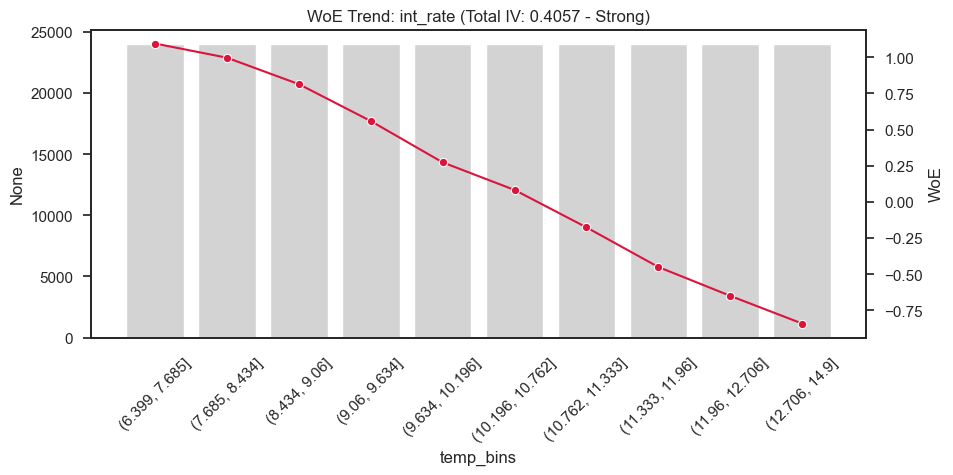

,Good,Bad,Prop_Good,Prop_Bad,%_Good,%_Bad,WoE,IV_Bin,Predictive_Power
"(6.399, 7.685]",23184,816,96.600000,3.400000,0.106768,0.035730,1.094672,0.077764,Weak
"(7.685, 8.434]",23103,897,96.262500,3.737500,0.106395,0.039274,0.996586,0.066892,Weak
"(8.434, 9.06]",22931,1069,95.545833,4.454167,0.105603,0.046801,0.813780,0.047852,Weak
"(9.06, 9.634]",22638,1362,94.325000,5.675000,0.104254,0.059623,0.558790,0.024939,Weak
"(9.634, 10.196]",22221,1779,92.587500,7.412500,0.102333,0.077871,0.273187,0.006683,Useless
"(10.196, 10.762]",21880,2120,91.166667,8.833333,0.100763,0.092793,0.082403,0.000657,Useless
"(10.762, 11.333]",21324,2676,88.850000,11.150000,0.098203,0.117123,-0.176194,0.003334,Useless
"(11.333, 11.96]",20600,3400,85.833333,14.166667,0.094868,0.148805,-0.450148,0.024280,Weak
"(11.96, 12.706]",19975,4025,83.229167,16.770833,0.091990,0.176155,-0.649683,0.054681,Weak
"(12.706, 14.9]",19292,4708,80.383333,19.616667,0.088845,0.206043,-0.841193,0.098586,Weak


In [32]:
# Recalling the function for individual feature
## To see the PLOT:
calculate_continuous_woe_iv(train_data, 'int_rate', 'default_status', bins=10, show_plot=True)
## To see the BINNED TABLE (instead of plot):
lo = calculate_continuous_woe_iv(train_data, 'int_rate', 'default_status', bins=10, show_plot=False)

#### Categorical features

In [33]:
def calculate_categorical_woe_iv(dataset, feature, target_col, show_plot=True, silent=False):
    # Ensure we only work with relevant columns and drop NAs
    df = dataset[[feature, target_col]].dropna().copy()
    if df.empty: return None, 0
    
    ## Step 1: Create frequency table
    # For categorical data, we group by the raw category names
    df_woe = pd.crosstab(df[feature], df[target_col])

    # If only one class exists in target or feature is constant
    if df_woe.shape[1] < 2: return None, 0
    df_woe.columns = ['Good', 'Bad']
    
    # Sort categories by name
    df_woe = df_woe.sort_index()

    ## Step 2: Math calculations
    df_woe['Total_Bin'] = df_woe['Good'] + df_woe['Bad']
    total_good, total_bad = df_woe['Good'].sum(), df_woe['Bad'].sum()

    # Prop_Good/Bad = % within the bin
    df_woe['Prop_Good'] = (df_woe['Good'] / df_woe['Total_Bin']) * 100
    df_woe['Prop_Bad'] = (df_woe['Bad'] / df_woe['Total_Bin']) * 100

    # %_Good and %_Bad distribution
    df_woe['%_Good'] = (df_woe['Good'] + 0.5) / total_good
    df_woe['%_Bad'] = (df_woe['Bad'] + 0.5) / total_bad

    # WoE = log(%Good Distribution / %Bad Distribution)
    df_woe['WoE'] = np.log(df_woe['%_Good'] / df_woe['%_Bad'])

    # IV contribution per bin
    df_woe['IV_Bin'] = (df_woe['%_Good'] - df_woe['%_Bad']) * df_woe['WoE']
    iv_total = df_woe['IV_Bin'].sum()

    ## Power Categorization Logic
    def get_power(iv):
        if iv < 0.02: return "Useless"
        elif iv < 0.1: return "Weak"
        elif iv < 0.3: return "Medium"
        elif iv < 0.5: return "Strong"
        else: return "Very Strong (Check Leakage)"

    df_woe['Predictive_Power'] = df_woe['IV_Bin'].apply(get_power)
    total_power = get_power(iv_total)

    ## Step 3: Summary Row
    summary_row = pd.DataFrame({
        'Good': [total_good],
        'Bad': [total_bad],
        'Total_Bin': [total_good + total_bad],
        'Prop_Good': [np.nan],
        'Prop_Bad': [np.nan],
        '%_Good': [1.0], 
        '%_Bad': [1.0],
        'WoE': [np.nan],
        'IV_Bin': [iv_total],
        'Predictive_Power': [f"TOTAL: {total_power}"]
    }, index=['Total Summary'])

    final_table = pd.concat([df_woe, summary_row])

    ## Step 4: Output
    if not silent:
        if show_plot:
            plt.figure(figsize=(12, 5))
            # Bar chart for volumes
            ax1 = sns.barplot(x=df_woe.index, y=df_woe['Total_Bin'], color='skyblue')
            plt.xticks(rotation=45)
            # Line chart for WoE trend
            ax2 = ax1.twinx()
            sns.lineplot(x=df_woe.index, y=df_woe['WoE'], marker='o', color='crimson', ax=ax2)
            plt.title(f"Categorical WoE: {feature} (Total IV: {iv_total:.4f} - {total_power})")
            plt.show()
        else:
            display(HTML(f"<h3>Categorical WoE Analysis for {feature}</h3>"))
            display(final_table[['Good', 'Bad', 'Prop_Good', 'Prop_Bad', '%_Good', '%_Bad', 'WoE', 'IV_Bin', 'Predictive_Power']])
            
    return df_woe, iv_total

In [34]:
# IV score summary for categorical variable
target = 'default_status'
categorical_cols = [c for c in train_data.select_dtypes(include=['object', 'category']).columns if c != target]
cat_iv_results = []

for col in categorical_cols:
    try:
        # Using silent=True to build the summary table first
        _, iv_value = calculate_categorical_woe_iv(train_data, col, target, silent=True)
        
        if iv_value > 0:
            if iv_value < 0.02: power = "Useless"
            elif iv_value < 0.1: power = "Weak"
            elif iv_value < 0.3: power = "Medium"
            elif iv_value < 0.5: power = "Strong"
            else: power = "Very Strong (Check Leakage)"
            
            cat_iv_results.append({'Feature': col, 'IV': iv_value, 'Power': power})
            
    except Exception as e:
        print(f"Skipping {col}: {e}")

# Display Summary
if cat_iv_results:
    cat_iv_df = pd.DataFrame(cat_iv_results).sort_values(by='IV', ascending=False)
    display(HTML("<h2>Categorical Feature Importance (IV)</h2>"))
    display(cat_iv_df)

,Feature,IV,Power
8,collateral,1.675870e+00,Very Strong (Check Leakage)
9,regularity_of_inflows,1.030796e+00,Very Strong (Check Leakage)
13,ltv_group,5.106552e-01,Very Strong (Check Leakage)
6,interest_band,3.728194e-01,Strong
7,grade,3.592881e-01,Strong
15,emp_length_group,5.227324e-04,Useless
4,addr_cities,4.247251e-04,Useless
1,emp_title,3.003676e-04,Useless
5,purpose,2.297589e-04,Useless
0,gender,1.175152e-04,Useless


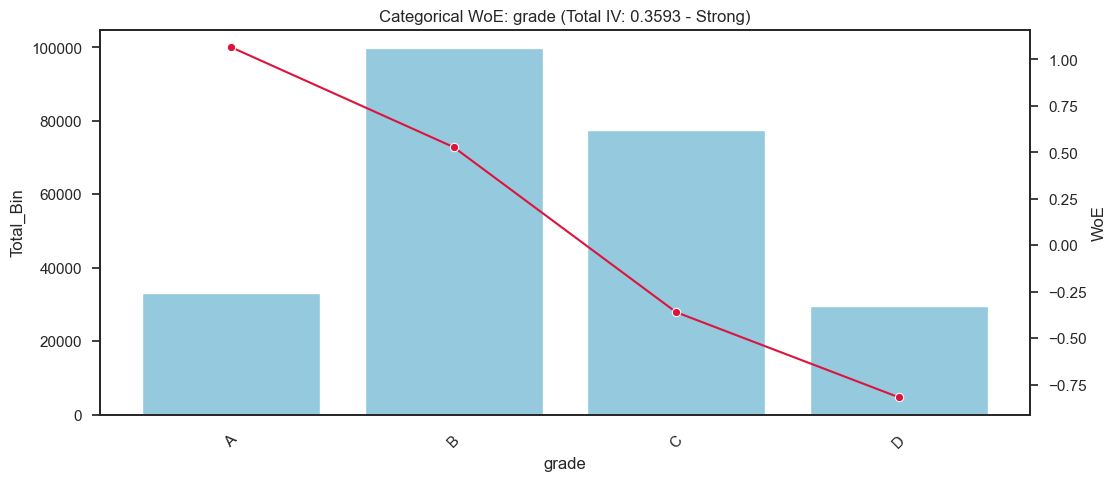

,Good,Bad,Prop_Good,Prop_Bad,%_Good,%_Bad,WoE,IV_Bin,Predictive_Power
A,31980,1159,96.502610,3.497390,0.147275,0.050740,1.065597,0.102868,Medium
B,93971,5833,94.155545,5.844455,0.432753,0.255273,0.527834,0.093680,Weak
C,67236,10146,86.888424,13.111576,0.309634,0.444009,-0.360453,0.048436,Weak
D,23961,5714,80.744735,19.255265,0.110346,0.250066,-0.818099,0.114304,Medium
Total Summary,217148,22852,NaN,NaN,1.000000,1.000000,NaN,0.359288,TOTAL: Strong


In [35]:
# Recalling the function
## To see the PLOT:
calculate_categorical_woe_iv(train_data, 'grade', 'default_status', show_plot=True)
## To see the BINNED TABLE (instead of plot):
lo = calculate_categorical_woe_iv(train_data, 'grade', 'default_status', show_plot=False)

### Filtered high IV score for continuous feature

In [36]:
# Filter the continuous features with IV > 0.5
high_iv_cont = cont_iv_df[cont_iv_df['IV'] > 0.5]

# Display the result
if not high_iv_cont.empty:
    display(HTML("<h4 style='color: #d9534f;'>🚨 High Risk: Potential Data Leakage detected in following Numerical Features</h4>"))
    display(high_iv_cont)
    
    # Create a list of names in case of needing to use them later (e.g., to drop or investigate)
    leakage_cont_feature = high_iv_cont['Feature'].tolist()
    print(f"⚠️ Alert: {len(high_iv_cont)} features found with IV > 0.5")
    print(f"Features to investigate: {leakage_cont_feature}")
else:
    display(HTML("<h4 style='color: #5cb85c;'>✅ No Data Leakage Detected</h4>"))
    print("All features have IV scores below 0.5.")

,Feature,IV,Power
7,loan_to_value,0.563911,Very Strong (Check Leakage)


⚠️ Alert: 1 features found with IV > 0.5
Features to investigate: ['loan_to_value']


In [37]:
# Define a function to perform a detailed leakage audit
def forensic_leakage_continuous_audit(df, leakage_features, target_col):
    """
    Audits continuous features for suspected data leakage.
    Analyzes feature-target relationships using Kernel Density Estimation (KDE) plots for visual separation and 
    Point-Biserial Correlation for statistic
    Args:
        df (pd.DataFrame): The dataset containing features and target.
        leakage_features (list): List of continuous column names to investigate.
        target_col (str): Name of the binary target variable.

    Returns:
        pd.DataFrame: A summary table containing correlation coefficients and p-values.
    """
    
    # If no features are passed, stop the function early
    if not leakage_features:
        print("No high-IV features provided for audit.")
        return None
    # Create an empty list to store results for each feature
    audit_data = []
    
    # VISUALIZATION Section
    print("🎨 Generated Data Leakage Visualization")
    # Count how many features we are analyzing
    num_feats = len(leakage_features)
    # Create subplots (2 plots per row)
    fig, axes = plt.subplots((num_feats + 1) // 2, 2, figsize=(20, 6 * ((num_feats + 1) // 2)))
    axes = axes.flatten()
    
    # Define custom colors: 0 (Good) = Green, 1 (Default/Risk) = Red
    custom_palette = {0: "#5cb85c", 1: "#d9534f"}

    # Loop through each feature
    for i, col in enumerate(leakage_features):
        # Set the current active subplot
        plt.sca(axes[i])
        
        # Create KDE plot with custom Red/Green palette
        sns.kdeplot(data=df, x=col, hue=target_col, 
            fill=True, palette=custom_palette, common_norm=False)
        
        # Set the title with your requested formatting
        plt.title(f"Distribution Analysis: {col} by {target_col}", fontsize=15, pad=20, fontweight='bold')
        
        # STATISTICAL CALCULATIONS ---
        # Calculate point-biserial correlation
        pb_corr, p_value = stats.pointbiserialr(df[target_col], df[col])
        
        # Group data by target classes
        stats_grp = df.groupby(target_col)[col].agg(['count', 'mean', 'std'])
        
        # Store results for the final table
        audit_data.append({
            'Feature': col,
            'Point-Biserial Corr': round(pb_corr, 4), # correlation strength
            'P-Value': f"{p_value:.4e}",              # statistical significance
            # Statistics for Class 0 (non-default)
            'Class 0 (Count)': stats_grp.loc[0, 'count'],
            'Class 0 (Mean)': round(stats_grp.loc[0, 'mean'], 4),
            'Class 0 (Std)': round(stats_grp.loc[0, 'std'], 4),
            # Statistics for Class 1 (default)
            'Class 1 (Count)': stats_grp.loc[1, 'count'],
            'Class 1 (Mean)': round(stats_grp.loc[1, 'mean'], 4),
            'Class 1 (Std)': round(stats_grp.loc[1, 'std'], 4),
            'Sample Size': len(df[col].dropna())})

    # Remove any unused subplot spaces
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

    # FINAL AUDIT table
    audit_df = pd.DataFrame(audit_data)
    display(HTML("<h3 style='color: #d9534f;'>🔍 Comprehensive Data Leakage Audit Report</h3>"))
    
    # Stylizing the table for easier reading
    styled_df = audit_df.sort_values(by='Point-Biserial Corr', ascending=False).style.background_gradient(
        subset=['Point-Biserial Corr'], cmap='RdYlGn_r'
    ).format(precision=4)
    # Show the final styled table in the notebook
    display(styled_df)
    return audit_df

🎨 Generated Data Leakage Visualization


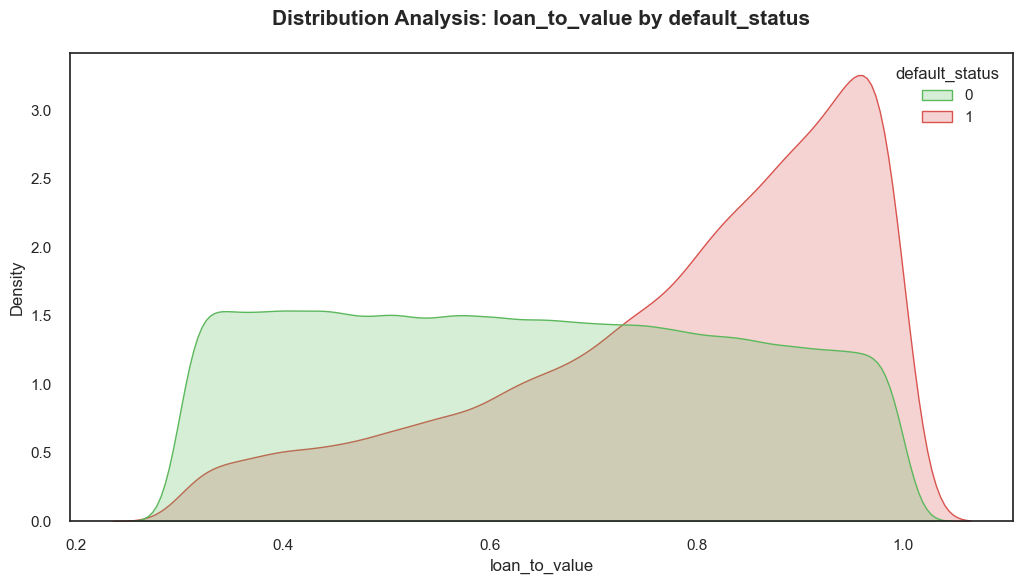

,Feature,Point-Biserial Corr,P-Value,Class 0 (Count),Class 0 (Mean),Class 0 (Std),Class 1 (Count),Class 1 (Mean),Class 1 (Std),Sample Size
0,loan_to_value,0.2117,0.0000e+00,361914,0.6359,0.1995,38086,0.7816,0.1773,400000


In [38]:
# Visualize the potential data leakage by comparing distributions against the target variable
# Ensure the target is numeric (0 or 1) for the correlation to work correctly
audit_continuous_leakage = forensic_leakage_continuous_audit(df, leakage_cont_feature, target)

VERDICT: No Leakage

Reasoning:
- No Perfect Seperation: If leakage occurred, the red and green distributions would be almost entirely separate. 
- Point-Biserial Correlation: 0.2117 (Moderate signal, not suspiciously high).
- Mean Difference: ~0.15 (Defaulters have higher LTVs on average).
- P-Value: 0.000 (Relationship is statistically significant).

### Filtered high IV score for categorical feature

In [39]:
# Filter the categorical features with IV > 0.5
high_iv_cat = cat_iv_df[cat_iv_df['IV'] > 0.5]

# Display the result
if not high_iv_cat.empty:
    display(HTML("<h4 style='color: #d9534f;'>🚨 High Risk: Potential Data Leakage detected in following Categorical Features</h4>"))
    display(high_iv_cat)
    
    # Create a list of names in case of needing to use them later (e.g., to drop or investigate)
    leakage_cat_features = high_iv_cat['Feature'].tolist()
    print(f"⚠️ Alert: {len(high_iv_cat)} categorical features found with IV > 0.5")
    print(f"Features to investigate: {leakage_cat_features}")
else:
    display(HTML("<h4 style='color: #5cb85c;'>✅ No Data Leakage Detected in Categorical Features</h4>"))
    print("All categorical features have IV scores below 0.5.")

,Feature,IV,Power
8,collateral,1.675870,Very Strong (Check Leakage)
9,regularity_of_inflows,1.030796,Very Strong (Check Leakage)
13,ltv_group,0.510655,Very Strong (Check Leakage)


⚠️ Alert: 3 categorical features found with IV > 0.5
Features to investigate: ['collateral', 'regularity_of_inflows', 'ltv_group']


In [40]:
def forensic_leakage_categorical_audit(df, leakage_features, target_col):
    """
    Audit categorical features for suspected of Data Leakage.
    Uses Normalized Stacked Bar for visualization and Chi-Square/Cramér's V for statistics.
    """
    if not leakage_features:
        print("No high-IV categorical features provided for audit.")
        return None

    audit_data = []
    num_feats = len(leakage_features)
    nrows = (num_feats + 1) // 2
    
    print(f"🎨 Generating Categorical Data Leakage Visualization")
    
    # Increase figsize to accommodate external legend
    fig, axes = plt.subplots(nrows, 2, figsize=(22, 7 * nrows))
    
    if num_feats == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    custom_colors = ["#5cb85c", "#d9534f"]

    for i, col in enumerate(leakage_features):
        ax = axes[i]
        
        # VISUALIZATION: 100% STACKED BAR
        cross_tab = pd.crosstab(df[col], df[target_col], normalize='index')
        
        # Remove automatic legend to place it manually later
        cross_tab.plot(kind='bar', stacked=True, ax=ax, color=custom_colors, edgecolor='white', legend=False)
        
        # Styling & Borders
        ax.set_title(f"Target Distribution: {col}", fontsize=16, pad=25, fontweight='bold')
        ax.set_ylabel("Proportion", fontsize=12)
        ax.set_xlabel(col, fontsize=12)
        ax.tick_params(axis='x', rotation=45)
        
        # Add a light grey border around the subplot to distinguish sections
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('#CCCCCC')
            spine.set_linewidth(1.5)

        # Position legend outside the plot to the right
        ax.legend(
            labels=['Non-Default (0)', 'Default (1)'], 
            title=target_col, 
            bbox_to_anchor=(1.02, 1), # Places legend just outside the right border
            loc='upper left', 
            borderaxespad=0,
            frameon=True)

        # STATISTICAL calculation
        # Chi2 test : The raw score of how much the actual data differs from what we'd expect if there were no relationship.
        contingency_table = pd.crosstab(df[col], df[target_col])
        chi2, p, dof, ex = stats.chi2_contingency(contingency_table)
        
        n = contingency_table.sum().sum()
        phi2 = chi2 / n
        r, k = contingency_table.shape # r = number of rows, k = number of columns
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
        rcorr = r - ((r-1)**2)/(n-1)
        kcorr = k - ((k-1)**2)/(n-1)
        
        cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1))) if min((kcorr-1), (rcorr-1)) > 0 else np.sqrt(phi2)
        max_concentration = cross_tab.max(axis=1).max() # Spotting if any specific group is almost 100% predictable

        audit_data.append({
            'Feature': col,
            'Cramér\'s V': round(cramers_v, 4),
            'P-Value': f"{p:.4e}",
            'DOF': dof,
            'Unique Categories': df[col].nunique(),
            'Max Class Concentration': round(max_concentration, 4),
            'Sample Size': len(df[col].dropna())
        })

    # Clean up empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    # Adjust layout with extra padding for the legend
    plt.tight_layout(rect=[0, 0, 0.9, 1]) 
    plt.subplots_adjust(hspace=0.4, wspace=0.4) # Add clear horizontal/vertical space between plots
    plt.show()

    # FINAL AUDIT table
    audit_df = pd.DataFrame(audit_data)
    display(HTML("<h3 style='color: #d9534f;'>🔍 Comprehensive Categorical Data Leakage Audit Report</h3>"))
    
    styled_df = audit_df.sort_values(by='Cramér\'s V', ascending=False).style.background_gradient(
        subset=['Cramér\'s V', 'Max Class Concentration'], cmap='YlOrRd'
    ).format(precision=4)
    
    display(styled_df)
    return audit_df

🎨 Generating Categorical Data Leakage Visualization


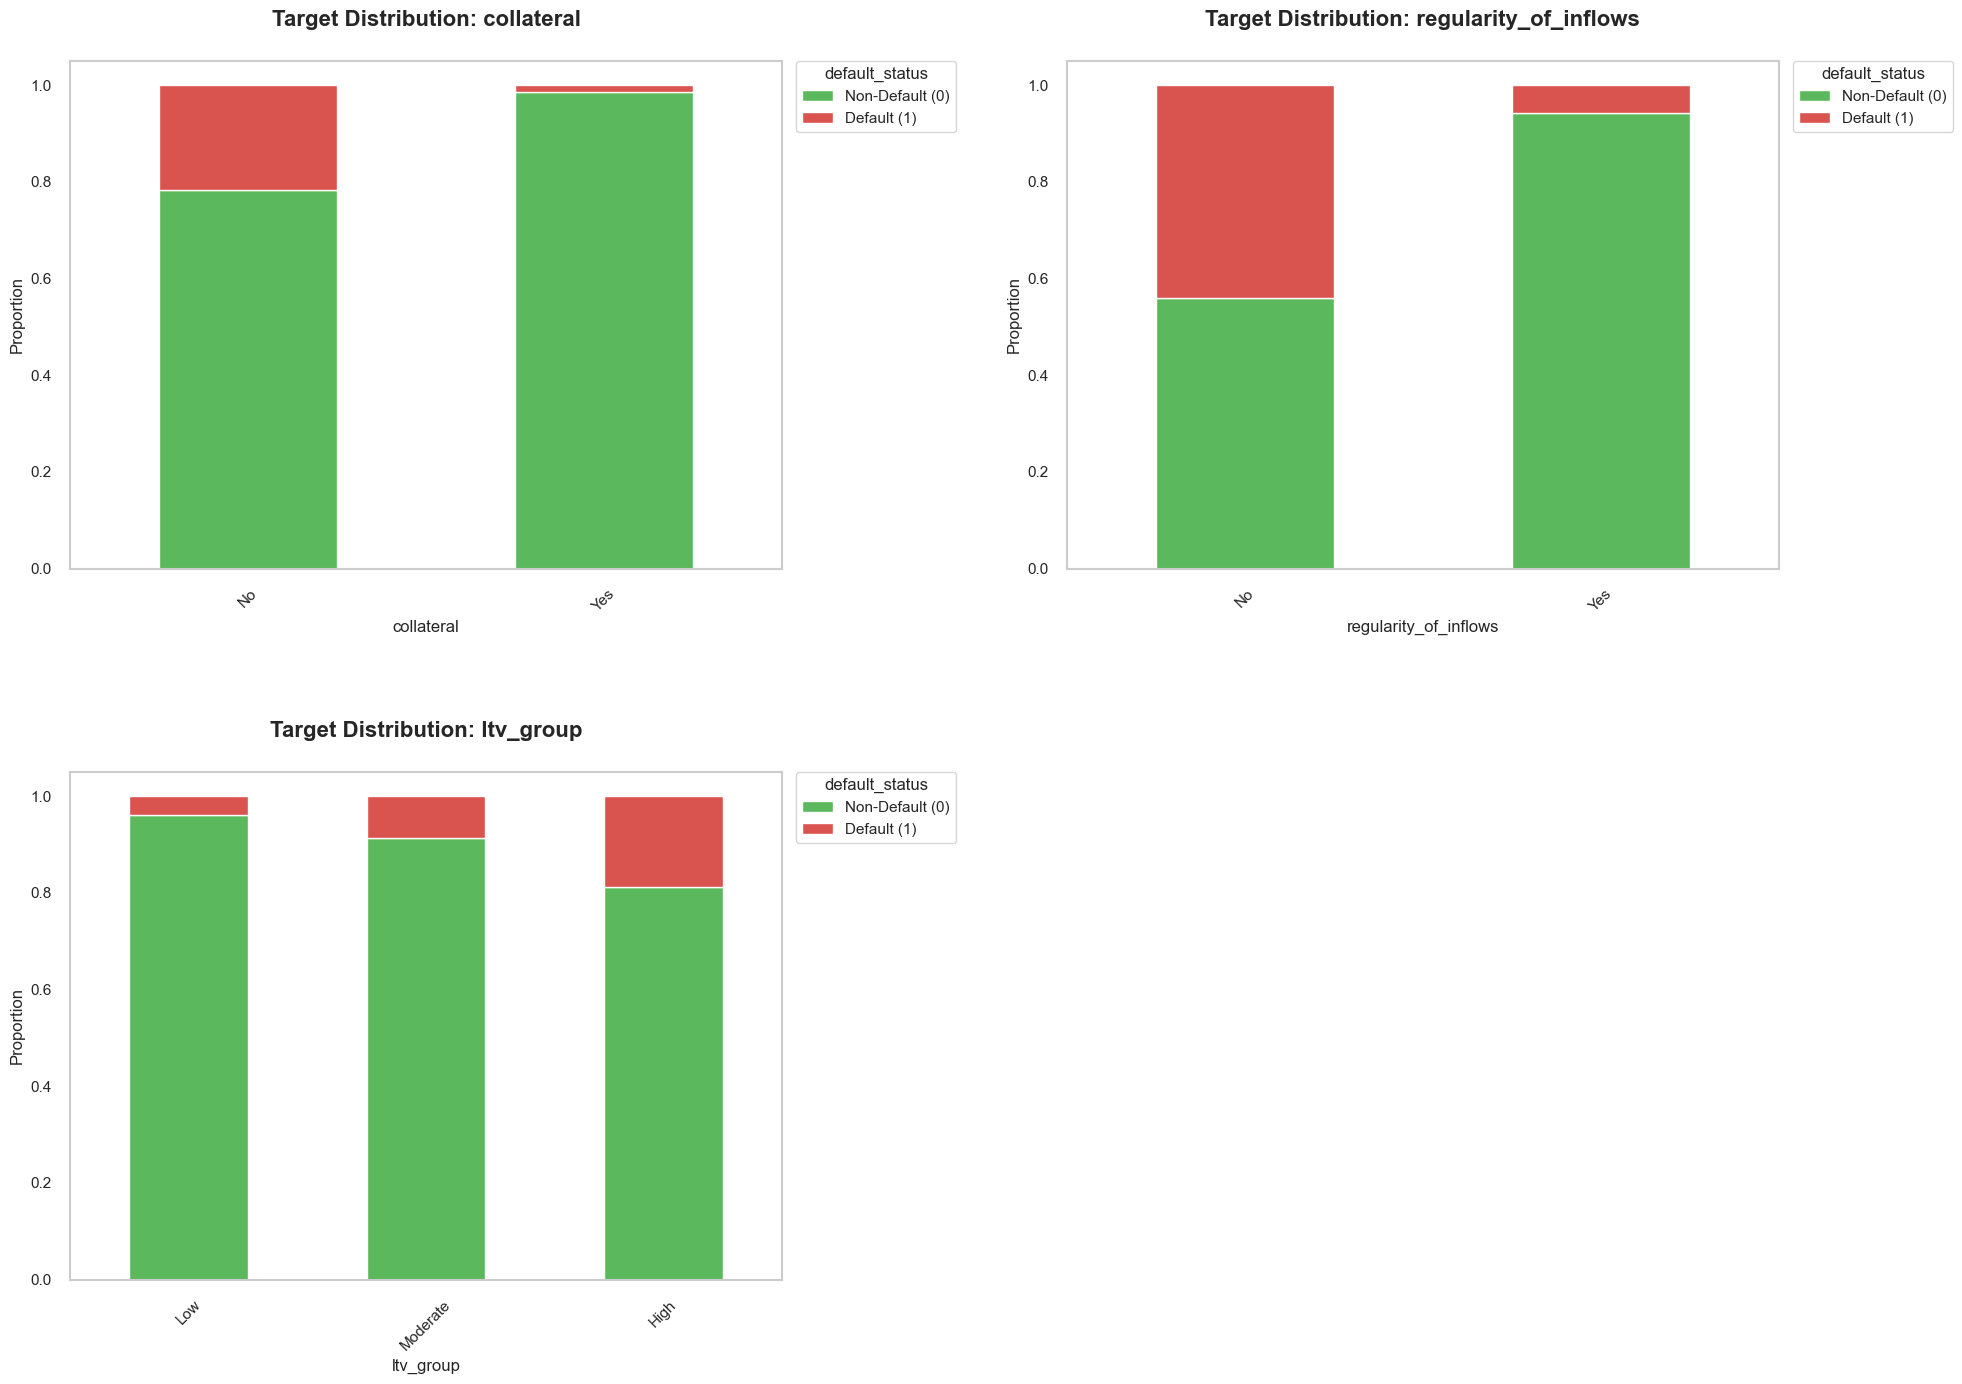

,Feature,Cramér's V,P-Value,DOF,Unique Categories,Max Class Concentration,Sample Size
1,regularity_of_inflows,0.3911,0.0000e+00,1,2,0.9429,400000
0,collateral,0.3391,0.0000e+00,1,2,0.9861,400000
2,ltv_group,0.2109,0.0000e+00,2,3,0.9612,400000


In [41]:
audit_categorical_leakage = forensic_leakage_categorical_audit(df, leakage_cat_features, target)

Cramer’s V intepretation

| Degrees of Freedom (DOF) | Small Effect | Medium Effect | Large Effect |
|:---:|:---:|:---:|:---:|
| **1** | 0.10 | 0.30 | 0.50 |
| **2** | 0.07 | 0.21 | 0.35 |
| **3** | 0.06 | 0.17 | 0.29 |
| **4** | 0.05 | 0.15 | 0.25 |
| **5** | 0.04 | 0.13 | 0.22 |

Source: https://www.statology.org/interpret-cramers-v/

1. regularity_of_inflows
- Stats: Cramér's V = 0.3911 | DOF = 1 | Max Concentration = 0.9429
- Interpretation: For DOF = 1, a Cramér’s V of 0.3911 indicates a moderate-to-strong association with the target variable, positioned between conventional “medium” (0.30) and “large” (0.50) thresholds.
- Verdict: This variable demonstrates strong predictive capability without clear evidence of leakage. It represents a robust and reliable feature suitable for inclusion in the model.

2. collateral 
- Stats: Cramér's V = 0.3391 | DOF = 1 | Max Concentration = 0.9861
- Interpretation: While the overall association is moderate, the very high class concentration (98.6%) suggests that at least one category (e.g., presence of collateral) is highly indicative of a single outcome.
- Verdict: This feature may carry predictive value, but the extreme concentration raises concerns about:
    - potential data leakage, or
    - over-dominant category effects

3. ltv_group
- Stats: Cramér's V = 0.2109 | DOF = 2 | Max Concentration = 0.9612
- Interpretation: Given DOF = 2, a Cramér’s V of 0.2109 corresponds to a moderate (medium) level of association. Although one category exhibits high class concentration, the overall relationship across categories remains balanced.
- Verdict: This is a moderately predictive and structurally sound feature. The absence of excessively high association suggests low risk of leakage, making it appropriate for inclusion in the model.

### Potential Data Leakage analysis

In [42]:
# Define function for continuous
def audit_continuous_stability_triple_split(train_df, test_df, holdout_df, feature, target, bins=10):
    """
    Audits stability across Train, Test, and Holdout sets for continuous variables.
    """
    results = {}
    
    # 1. Define Bins based ONLY on Train data to avoid leakage
    # We use retbins=True to get the exact edge values
    _, bin_edges = pd.qcut(train_df[feature], q=bins, retbins=True, duplicates='drop', precision=2)
    
    # Ensure the edges cover the full range of Test/Holdout by adjusting min/max
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    datasets = [
        ('Training', train_df),
        ('Testing', test_df),
        ('Holdout', holdout_df)
    ]

    for name, data in datasets:
        # 2. Apply the Training bins to the current dataset
        binned_series = pd.cut(data[feature], bins=bin_edges)
        
        # 3. Create Cross-tab
        ct = pd.crosstab(binned_series, data[target]).astype(float)
        
        woe_df = pd.DataFrame()
        woe_df['Total'] = ct.sum(axis=1)
        woe_df['Events'] = ct[1] if 1 in ct.columns else 0
        woe_df['Non-Events'] = woe_df['Total'] - woe_df['Events']
        
        # Laplace Smoothing to prevent division by zero
        e_sum = woe_df['Events'].sum()
        ne_sum = woe_df['Non-Events'].sum()
        
        event_dist = (woe_df['Events']) / e_sum
        non_event_dist = (woe_df['Non-Events']) / ne_sum
        
        # WoE and IV Calculations
        woe_df['WoE'] = np.log(non_event_dist / event_dist)
        woe_df['IV_Contrib'] = (non_event_dist - event_dist) * woe_df['WoE']
        iv_total = woe_df['IV_Contrib'].sum()
        
        results[name] = {'table': woe_df, 'iv': iv_total}

    # STABILITY report
    tr_iv = results['Training']['iv']
    te_iv = results['Testing']['iv']
    ho_iv = results['Holdout']['iv']
    
    # Create Comparison Table
    stability_compare = pd.DataFrame({
        'Train_WoE': results['Training']['table']['WoE'],
        'Test_WoE': results['Testing']['table']['WoE'],
        'Holdout_WoE': results['Holdout']['table']['WoE']
    })
    
    # Calculate shift between Train and Holdout (the ultimate test)
    stability_compare['Max_WoE_Delta'] = stability_compare.max(axis=1) - stability_compare.min(axis=1)

    # Calculate the Overall Maximum Delta across all bins ---
    overall_max_delta = stability_compare['Max_WoE_Delta'].max()
    
    print(f"📊 TRIPLE-SPLIT STABILITY AUDIT: {feature}")
    print("-" * 50)
    
    stats_summary = pd.DataFrame({
        'Metric': ['In-Sample (Train)', 'Validation (Test)', 'Unseen (Holdout)'],
        'IV Score': [f"{tr_iv:.4f}", f"{te_iv:.4f}", f"{ho_iv:.4f}"],
        'Retention (vs Train)': ["100%", f"{(te_iv/tr_iv)*100:.1f}%", f"{(ho_iv/tr_iv)*100:.1f}%"]
    })
    display(stats_summary)
    
    display(HTML(f"<h4>WoE Consistency Across All Sets:</h4>"))
    display(stability_compare.style.background_gradient(subset=['Max_WoE_Delta'], cmap='YlOrRd'))

    # Final Verdict Logic
    ho_retention = ho_iv / tr_iv
    if ho_retention < 0.75:
        print(f"❌ REJECT: IV dropped to {ho_retention*100:.1f}% on Holdout. High risk of overfit.")
    elif overall_max_delta > 0.25:
        print("⚠️ CAUTION: Significant WoE variance detected in specific bins.")
    else:
        print(f"✅ PASS: Feature demonstrates high stability (Max Delta: {overall_max_delta:.4f}) across all data splits.")

In [43]:
# Recombine X and y into temporary dataframes for the audit
train_full = pd.concat([X_train, y_train], axis=1)
test_full = pd.concat([X_test, y_test], axis=1)
holdout_full = pd.concat([X_holdout, y_holdout], axis=1)
audit_continuous_stability_triple_split(train_full, test_full, holdout_full, 'loan_to_value', 'default_status')

📊 TRIPLE-SPLIT STABILITY AUDIT: loan_to_value
--------------------------------------------------


,Metric,IV Score,Retention (vs Train)
0,In-Sample (Train),0.5641,100%
1,Validation (Test),0.5736,101.7%
2,Unseen (Holdout),0.5613,99.5%


,Train_WoE,Test_WoE,Holdout_WoE,Max_WoE_Delta
loan_to_value,,,,
"(-inf, 0.37]",1.339370,1.313940,1.326024,0.025430
"(0.37, 0.439]",1.087678,1.116860,1.130543,0.042865
"(0.439, 0.51]",0.946222,0.900570,0.919237,0.045652
"(0.51, 0.58]",0.675492,0.741791,0.756599,0.081107
"(0.58, 0.649]",0.457221,0.499901,0.387199,0.112702
"(0.649, 0.719]",0.212516,0.253029,0.160915,0.092114
"(0.719, 0.789]",-0.110007,-0.126581,-0.098645,0.027936
"(0.789, 0.859]",-0.474145,-0.487489,-0.462768,0.024721
"(0.859, 0.93]",-0.757615,-0.742044,-0.730926,0.026690


✅ PASS: Feature demonstrates high stability (Max Delta: 0.1127) across all data splits.


The feature loan_to_value passed the stability audit with an IV score of ~0.56, indicating it is a strong predictor for the model.
  - IV Score (Information Value): Measures the predictive power of the variable; a score above 0.3 is generally considered very strong.
  - Max_WoE_Delta: Represents the maximum difference in 'Weight of Evidence' between data splits. Low deltas mean the relationship between the feature and the target remains consistent across different datasets.
  - Retention (vs Train): Measures how much predictive power is kept in the Test/Holdout sets compared to Training. Scores near 100% (yours are 101.6% and 99.4%) confirm the model isn't overfitted and will perform reliably on new data.

In [44]:
audit_continuous_stability_triple_split(train_full, test_full, holdout_full, 'int_rate', 'default_status')

📊 TRIPLE-SPLIT STABILITY AUDIT: int_rate
--------------------------------------------------


,Metric,IV Score,Retention (vs Train)
0,In-Sample (Train),0.4058,100%
1,Validation (Test),0.4062,100.1%
2,Unseen (Holdout),0.3895,96.0%


,Train_WoE,Test_WoE,Holdout_WoE,Max_WoE_Delta
int_rate,,,,
"(-inf, 7.685]",1.095263,1.067760,1.153091,0.085331
"(7.685, 8.434]",0.997121,0.985270,0.879033,0.118088
"(8.434, 9.06]",0.814226,0.827704,0.824059,0.013478
"(9.06, 9.634]",0.559135,0.596964,0.525929,0.071036
"(9.634, 10.196]",0.273446,0.343448,0.232085,0.111363
"(10.196, 10.762]",0.082616,-0.019371,0.084105,0.103477
"(10.762, 11.333]",-0.176030,-0.129108,-0.176389,0.047281
"(11.333, 11.96]",-0.450025,-0.451253,-0.409953,0.041300
"(11.96, 12.706]",-0.649584,-0.620404,-0.696194,0.075790


✅ PASS: Feature demonstrates high stability (Max Delta: 0.1181) across all data splits.


In [45]:
# Define function for categorical and convert categorical columns to numeric before performing calculations
def audit_categorical_stability_triple_split(train_df, test_df, holdout_df, feature, target):
    """
    Audits stability across Train, Test (Validation), and Holdout sets 
    for categorical variables.
    """
    results = {}
    
    datasets = [
        ('Training', train_df),
        ('Testing', test_df),
        ('Holdout', holdout_df)
    ]

    for name, data in datasets:
        # Create cross-tab
        ct = pd.crosstab(data[feature], data[target]).astype(float)
        
        # Create WoE dataframe
        woe_df = pd.DataFrame()
        woe_df['Total'] = ct.sum(axis=1)
        woe_df['Events'] = ct[1] if 1 in ct.columns else 0
        woe_df['Non-Events'] = woe_df['Total'] - woe_df['Events']
        
        # Laplace Smoothing (+0.5) to prevent division by zero or log(inf)
        # This is critical when working with smaller validation/holdout slices
        e_sum = woe_df['Events'].sum()
        ne_sum = woe_df['Non-Events'].sum()
        
        event_dist = (woe_df['Events']) / e_sum
        non_event_dist = (woe_df['Non-Events']) / ne_sum
        
        # WoE: ln(Dist Non-Events / Dist Events)
        woe_df['WoE'] = np.log(non_event_dist / event_dist)
        
        # IV: (Dist Non-Events - Dist Events) * WoE
        woe_df['IV_Contrib'] = (non_event_dist - event_dist) * woe_df['WoE']
        iv_total = woe_df['IV_Contrib'].sum()
        
        results[name] = {'table': woe_df, 'iv': iv_total}

    # --- DISPLAY STABILITY REPORT ---
    tr_iv = results['Training']['iv']
    te_iv = results['Testing']['iv']
    ho_iv = results['Holdout']['iv']
    
    # Create Comparison Table
    stability_compare = pd.DataFrame({
        'Train_WoE': results['Training']['table']['WoE'],
        'Test_WoE': results['Testing']['table']['WoE'],
        'Holdout_WoE': results['Holdout']['table']['WoE']
    }).fillna(0) # Fill categories that might be missing in a specific split
    
    # Calculate Max Delta across the three splits to find the "weakest link"
    stability_compare['Max_WoE_Delta'] = stability_compare.max(axis=1) - stability_compare.min(axis=1)

    # Calculate the Overall Maximum Delta across all bins ---
    overall_max_delta = stability_compare['Max_WoE_Delta'].max()
    
    print(f"📊 CATEGORICAL STABILITY AUDIT: {feature}")
    print("-" * 55)
    
    # Summary Table for IV
    stats_summary = pd.DataFrame({
        'Metric': ['Training (60%)', 'Testing/Val (20%)', 'Holdout (20%)'],
        'IV Score': [f"{tr_iv:.4f}", f"{te_iv:.4f}", f"{ho_iv:.4f}"],
        'IV Retention': ["100%", f"{(te_iv/tr_iv)*100:.1f}%", f"{(ho_iv/tr_iv)*100:.1f}%"]
    })
    display(stats_summary)
    
    display(HTML(f"<h4>WoE Consistency Across Splits:</h4>"))
    display(stability_compare.style.background_gradient(subset=['Max_WoE_Delta'], cmap='YlOrRd'))

    # Final Verdict Logic
    ho_retention = ho_iv / tr_iv
    if ho_retention < 0.80:
        print(f"❌ REJECT: Significant IV decay on Holdout ({ho_retention*100:.1f}%). Overfitting likely.")
    elif stability_compare['Max_WoE_Delta'].max() > 0.20:
        print("⚠️ WARNING: High WoE variance in specific categories. Review category mapping.")
    else:
        print(f"✅ PASS: Feature demonstrates high stability (Max Delta: {overall_max_delta:.4f}) across all data splits.")

In [46]:
# Recombine X and y into temporary dataframes for the audit
train_full = pd.concat([X_train, y_train], axis=1)
test_full = pd.concat([X_test, y_test], axis=1)
holdout_full = pd.concat([X_holdout, y_holdout], axis=1)
audit_categorical_stability_triple_split(train_full, test_full, holdout_full, 'collateral', 'default_status')

📊 CATEGORICAL STABILITY AUDIT: collateral
-------------------------------------------------------


,Metric,IV Score,IV Retention
0,Training (60%),1.6760,100%
1,Testing/Val (20%),1.7161,102.4%
2,Holdout (20%),1.6957,101.2%


,Train_WoE,Test_WoE,Holdout_WoE,Max_WoE_Delta
collateral,,,,
No,-0.967092,-0.967476,-0.973080,0.005987
Yes,1.999467,2.053261,2.013921,0.053794


✅ PASS: Feature demonstrates high stability (Max Delta: 0.0538) across all data splits.


In [47]:
audit_categorical_stability_triple_split(train_full, test_full, holdout_full, 'regularity_of_inflows', 'default_status')

📊 CATEGORICAL STABILITY AUDIT: regularity_of_inflows
-------------------------------------------------------


,Metric,IV Score,IV Retention
0,Training (60%),1.0308,100%
1,Testing/Val (20%),0.9916,96.2%
2,Holdout (20%),1.0307,100.0%


,Train_WoE,Test_WoE,Holdout_WoE,Max_WoE_Delta
regularity_of_inflows,,,,
No,-2.018289,-1.996414,-2.018934,0.022521
Yes,0.556117,0.539032,0.555894,0.017085


✅ PASS: Feature demonstrates high stability (Max Delta: 0.0225) across all data splits.


In [48]:
audit_categorical_stability_triple_split(train_full, test_full, holdout_full, 'ltv_group', 'default_status')

📊 CATEGORICAL STABILITY AUDIT: ltv_group
-------------------------------------------------------


,Metric,IV Score,IV Retention
0,Training (60%),0.5107,100%
1,Testing/Val (20%),0.5260,103.0%
2,Holdout (20%),0.5088,99.6%


,Train_WoE,Test_WoE,Holdout_WoE,Max_WoE_Delta
ltv_group,,,,
Low,0.950676,0.984050,0.959018,0.033373
Moderate,0.099277,0.089768,0.080531,0.018746
High,-0.789380,-0.790209,-0.781972,0.008237


✅ PASS: Feature demonstrates high stability (Max Delta: 0.0334) across all data splits.


The feature collateral passed the stability audit with an IV score of ~1.6759, indicating it is a very strong predictor for the model.

- IV Score (Information Value): Measures predictive strength; scores > 0.5 are typically "suspiciously high" and require validation to ensure the variable is actually available at the time of prediction.
- Max_WoE_Delta: Measures the stability of the relationship between the feature and the target across datasets. The low delta (0.05) indicates the logic remains consistent and hasn't shifted between training and testing.
- Retention (vs Train): Shows how much predictive power is maintained outside of training. Scores of 102.4% and 101.2% mean the feature is just as effective (if not slightly more) on unseen data, confirming excellent generalization.

# Column to drop

In [49]:
# Identify the continuous features with 'Useless' power which take reference at the results from previous IV calculation loop
useless_continuous_features = [item['Feature'] for item in cont_iv_results if item['Power'] == "Useless" and item['Feature'].lower() != 'ead']

# Execute the Drop across all splits
if useless_continuous_features:
    print(f"🚫 Identified {len(useless_continuous_features)} useless continuous features to drop.")
    print(f"Dropping: {useless_continuous_features}")
    print(f"📌 Note: 'ead' was retained for Expected Loss calculations despite IV results.")    
    
    # Put the feature sets into a list to clean them all at once
    data_splits = [
        ('Training', X_train),
        ('Testing', X_test),
        ('Holdout', X_holdout)]
    
    for name, split_df in data_splits:
        # Use errors='ignore' to prevents the code from stopping if a column was already removed
        split_df.drop(columns=useless_continuous_features, errors='ignore', inplace=True)
        print(f"✅ Successfully dropped from {name} set.")
else:
    print("✨ Keep all features: No 'Useless' columns were found in the IV results.")

# Display the Summary Table
if cont_iv_results:
    # Filter the summary table to only show features with predictive power to keeps the notebook clean for stakeholders
    cont_iv_df_filtered = cont_iv_df[(cont_iv_df['Power'] != 'Useless') | (cont_iv_df['Feature'].str.lower() == 'ead')]
    display(HTML("<h2>Refined Feature Importance (Useless Dropped)</h2>"))
    display(cont_iv_df_filtered)

🚫 Identified 9 useless continuous features to drop.
Dropping: ['person_age', 'annual_inc', 'emp_length', 'loan_amount', 'term', 'terms_remaining', 'mths_since_earliest_cr_line', 'fixed_obligation', 'existing_emi']
📌 Note: 'ead' was retained for Expected Loss calculations despite IV results.
✅ Successfully dropped from Training set.
✅ Successfully dropped from Testing set.
✅ Successfully dropped from Holdout set.


,Feature,IV,Power
7,loan_to_value,5.639113e-01,Very Strong (Check Leakage)
6,int_rate,4.056663e-01,Strong
11,ead,3.832678e-10,Useless


In [50]:
# Identify the categorical features with 'Useless' power which take reference at the results from previous IV calculation loop
# EXCEPTION: We explicitly exclude 'purpose' from being dropped
useless_categorical_features = [item['Feature'] for item in cat_iv_results if item['Power'] == "Useless" and item['Feature'].lower() != 'purpose']

# Execute the Drop across all splits
if useless_categorical_features:
    print(f"🗑️ Found {len(useless_categorical_features)} useless categorical features to drop.")
    print(f"Dropping: {useless_categorical_features}")
    print(f"📌 Note: 'purpose' was retained for LGD calculation despite IV results.")

    # Put the feature sets into a list to clean them all at once
    target_splits = [
        ('Training (X_train)', X_train),
        ('Testing (X_test)', X_test),
        ('Holdout (X_holdout)', X_holdout)
    ]
    
    for name, df_split in target_splits:
        # Use errors='ignore' to prevents the code from stopping if a column was already removed
        df_split.drop(columns=useless_categorical_features, errors='ignore', inplace=True)
        print(f"✅ Successfully removed from {name}")
else:
    print("✨ No 'Useless' categorical features were found. All sets remain unchanged.")

# Display the Summary Table
if cat_iv_results:
    # Filter the summary dataframe to show only the useful features you kept
    cat_iv_df_refined = cat_iv_df[(cat_iv_df['Power'] != 'Useless') | (cat_iv_df['Feature'].str.lower() == 'purpose')]
    display(HTML("<h2>Refined Categorical Feature Importance (Final List)</h2>"))
    display(cat_iv_df_refined)

🗑️ Found 10 useless categorical features to drop.
Dropping: ['gender', 'emp_title', 'home_ownership', 'marriage_status', 'addr_cities', 'existing_loans', 'age_group', 'income_group', 'loan_amount_group', 'emp_length_group']
📌 Note: 'purpose' was retained for LGD calculation despite IV results.
✅ Successfully removed from Training (X_train)
✅ Successfully removed from Testing (X_test)
✅ Successfully removed from Holdout (X_holdout)


,Feature,IV,Power
8,collateral,1.675870,Very Strong (Check Leakage)
9,regularity_of_inflows,1.030796,Very Strong (Check Leakage)
13,ltv_group,0.510655,Very Strong (Check Leakage)
6,interest_band,0.372819,Strong
7,grade,0.359288,Strong
5,purpose,0.000230,Useless


In [51]:
# Re-inspect the train dataframe
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240000 entries, 154937 to 137588
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   purpose                240000 non-null  category
 1   int_rate               240000 non-null  float64 
 2   interest_band          240000 non-null  category
 3   grade                  240000 non-null  category
 4   loan_to_value          240000 non-null  float64 
 5   collateral             240000 non-null  category
 6   regularity_of_inflows  240000 non-null  category
 7   ltv_group              240000 non-null  category
 8   ead                    240000 non-null  float64 
dtypes: category(6), float64(3)
memory usage: 8.7 MB


In [52]:
# Re-inspect the test dataframe
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 353167 to 320141
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   purpose                80000 non-null  category
 1   int_rate               80000 non-null  float64 
 2   interest_band          80000 non-null  category
 3   grade                  80000 non-null  category
 4   loan_to_value          80000 non-null  float64 
 5   collateral             80000 non-null  category
 6   regularity_of_inflows  80000 non-null  category
 7   ltv_group              80000 non-null  category
 8   ead                    80000 non-null  float64 
dtypes: category(6), float64(3)
memory usage: 2.9 MB


In [53]:
# Re-inspect the holdout dataframe
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 253024 to 217992
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   purpose                80000 non-null  category
 1   int_rate               80000 non-null  float64 
 2   interest_band          80000 non-null  category
 3   grade                  80000 non-null  category
 4   loan_to_value          80000 non-null  float64 
 5   collateral             80000 non-null  category
 6   regularity_of_inflows  80000 non-null  category
 7   ltv_group              80000 non-null  category
 8   ead                    80000 non-null  float64 
dtypes: category(6), float64(3)
memory usage: 2.9 MB


In [54]:
y_train.value_counts()

default_status
0    217148
1     22852
Name: count, dtype: int64

# Exporting CSV files - Preprocessed data

In [55]:
# Define the designated directory path
base_path = r"C:/Users/danie/Downloads/Data Analytic/credit_loan_analysis"

try:
    # 1. Check/Create directory
    if not os.path.exists(base_path):
        os.makedirs(base_path)
    
    # 2. Attempt to save all files
    X_train.to_csv(os.path.join(base_path, 'loan_inputs_train.csv'), index=False)
    y_train.to_csv(os.path.join(base_path, 'loan_targets_train.csv'), index=False)
    X_test.to_csv(os.path.join(base_path, 'loan_inputs_test.csv'), index=False)
    y_test.to_csv(os.path.join(base_path, 'loan_targets_test.csv'), index=False)
    X_holdout.to_csv(os.path.join(base_path, 'loan_inputs_holdout.csv'), index=False)
    y_holdout.to_csv(os.path.join(base_path, 'loan_targets_holdout.csv'), index=False)

except PermissionError:
    print("Error: File was not saved. Please check folder permission.")
except FileNotFoundError:
    print(f"Error: The directory path '{base_path}' could not be found or created.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

else:
    # This block runs ONLY if the try block succeeds perfectly
    print("Success: All training, testing, and holdout sets have been saved successfully.")
    print(f"Location: {base_path}")

Success: All training, testing, and holdout sets have been saved successfully.
Location: C:/Users/danie/Downloads/Data Analytic/credit_loan_analysis


# Exporting the notebook

In [56]:
import shutil

# Define your source and destination
current_notebook_name = "credit_loan_preprocess.ipynb" 
destination_path = r"C:\Users\danie\Downloads\Data Analytic\credit_loan_analysis"

# Ensure destination exists
if not os.path.exists(destination_path):
    os.makedirs(destination_path)

# Perform the copy
try:
    # This looks for the file in the current working directory
    shutil.copy(current_notebook_name, os.path.join(destination_path, current_notebook_name))
    print(f"✅ Notebook successfully copied to: {destination_path}")
except FileNotFoundError:
    print(f"❌ Error: Could not find '{current_notebook_name}'.")
    print("👉 Make sure the filename matches exactly and you have saved (Ctrl+S) recently.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Notebook successfully copied to: C:\Users\danie\Downloads\Data Analytic\credit_loan_analysis
